<a href="https://colab.research.google.com/github/babi00/ai4biological-pattern/blob/guido-clean/invasive_plants_analysis/testing_strategies_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Classificatore specie:
- input: immagine
- output label: nativa/non nativa e non invasiva/non nativa e invasiva
La struttura del modello utilizzato è simile a quella precedentemente implementata:
le immagini passano attraverso un modello preallenato (BioCLIP o ResNet) da cui vengono estratti gli embedding
gli embedding allenano un semplice classificatore.

La loss function è stata modificata: ogni classe ha il suo peso (dipendente dalla frequenza della classe).

Durante il training le fasi di estrazione degli embedding e predizione del label sono separate (così che il training sia molto più veloce e leggero). Una volta finito il training viene ricostruito il modello intero, così che il classificatore prenda come input l'immagine (non l'embedding) e restituisca il label (in modo che si possa effettuare successivamente explainability sulle immagini e non solo sugli embedding).

Rispetto al modello di Barbara, estraggo gli embeddings tutti insieme (e non separati per training set e validation set), così da poter effettuare cross validation senza dover ogni volta estrarre gli embeddings.

In [1]:
#@title Imports and downloads
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import functional as TF
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, ConcatDataset
from torchvision import transforms, models
from sklearn.metrics import classification_report, multilabel_confusion_matrix, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import GroupKFold
from google.colab import drive
import time
from tqdm import tqdm
!pip install open_clip_torch
import open_clip
import math
from collections import Counter
import datetime
import json
import os

torch.manual_seed(42)
np.random.seed(42)

drive.mount('/content/drive')

# Clone the repository and checkout the 'clean-barbara' branch
!git clone --branch clean-barbara https://github.com/babi00/ai4biological-pattern.git
%cd ai4biological-pattern

# Enable sparse checkout
!git sparse-checkout init --cone

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
fatal: destination path 'ai4biological-pattern' already exists and is not an empty directory.
/content/ai4biological-pattern


In [2]:
#@title Training log saving function
def save_training_log(model_name, output_dir, train_losses, val_losses, train_accuracies, val_accuracies, classification_report_dict):
    import datetime
    import json
    import os

    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    log_dir = f"/content/drive/MyDrive/Thesis/{output_dir}/logs"
    os.makedirs(log_dir, exist_ok=True)
    log_path = os.path.join(log_dir, "training_log.json")

    # Load existing logs (if any)
    if os.path.exists(log_path):
        with open(log_path, "r") as f:
            all_logs = json.load(f)
    else:
        all_logs = []

    # Prepare this run's data
    this_log = {
        "model_name": model_name,
        "timestamp": timestamp,
        "final_train_loss": train_losses[-1] if train_losses else None,
        "final_val_loss": val_losses[-1] if val_losses else None,
        "final_train_accuracy": train_accuracies[-1] if train_accuracies else None,
        "final_val_accuracy": val_accuracies[-1] if val_accuracies else None,
        "classification_report_last_epoch": classification_report_dict[-1] if isinstance(classification_report_dict, list) else classification_report_dict,
        "train_loss_history": train_losses,
        "val_loss_history": val_losses,
        "train_accuracy_history": train_accuracies,
        "val_accuracy_history": val_accuracies
    }

    all_logs.append(this_log)

    # Save updated list
    with open(log_path, "w") as f:
        json.dump(all_logs, f, indent=4)

    print(f"📝 Appended log to {log_path}")


In [3]:
#@title Horizontal flip
def hflip(image):
  return TF.hflip(image)

In [4]:
#@title Original Dataset
class InvasiveSpeciesDataset(Dataset):
    def __init__(self, root_dir, transform=None, get_label_fn=None):
        self.root_dir = root_dir
        self.transform = transform
        self.entries = []
        self.label_map = {
            "Invasive" : 0,
            "Non Invasive" : 1
        }

        taxa_folders = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d)) and d != "metadata"]
        for taxon in taxa_folders:
            meta_path = os.path.join(root_dir, "filtered_metadata", f"{taxon}_metadata.csv")
            if not os.path.exists(meta_path):
                continue
            metadata_df = pd.read_csv(meta_path)
            # for idx, row in metadata_df.iterrows():
            #     self.entries.append((taxon, row))  # Just index, don’t open anything
            for idx, row in metadata_df.iterrows():
              if pd.isna(row["filename"]):
                  print(f"⚠️ Missing filename in taxon '{taxon}' at index {idx}")
                  continue
              self.entries.append((taxon, row))

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        taxon, row = self.entries[idx]
        filename = str(row["filename"])
        image_path = os.path.join(self.root_dir, taxon, filename)
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = self.label_map.get(row["label"])
        return image, label, idx

In [5]:
#@title Augmented Dataset
class AugmentedDataset(Dataset):
  def __init__(self, original_dataset, transform=None):
    self.original_dataset = original_dataset
    self.transform = transform
    self.entries = [entry for entry in original_dataset.entries]
    self.root_dir = original_dataset.root_dir
    self.label_map = {
            "Invasive" : 0,
            "Non Invasive" : 1
        }

  def __len__(self):
    return len(self.entries)

  def __getitem__(self, idx):
    taxon, row = self.entries[idx]
    filename = str(row['filename'])
    image_path = os.path.join(self.root_dir, taxon, filename)
    image = Image.open(image_path).convert("RGB")
    if self.transform:
        image = self.transform(image)
    label = self.label_map.get(row["label"])
    return image, label, idx

In [6]:
#@title Return the dataloader of all images and not already separated (also class weights are not present)
def get_data_loader(root_dir, batch_size=32, use_bioclip=True, preprocess=None):
    if use_bioclip and preprocess:
        transform = preprocess
    else:
        transform = transforms.Compose([
          transforms.Resize((224, 224)),
          transforms.ToTensor()
        ])

    dataset = InvasiveSpeciesDataset(
        root_dir=root_dir,
        transform=transform,
    )

    loader = DataLoader(dataset, batch_size=32, shuffle=False)

    return loader

In [7]:
#@title Augmentation helper functions
def get_augmented_transform_flipping(preprocess=None):

    if preprocess:
        # BioCLIP: use its own preprocessing, plus flipping
        return transforms.Compose([
            transforms.Lambda(lambda img: TF.hflip(img)),
            preprocess
        ])
    else:
        # ResNet or default: manual transform
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.Lambda(lambda img: TF.hflip(img)),
            transforms.ToTensor()
        ])


def get_augmented_transform_jitter(preprocess=None):

    if preprocess:
        # BioCLIP: use its own preprocessing, plus jittering (no hue modification)
        return transforms.Compose([
            transforms.ColorJitter(0.3, 0.3, 0.3),
            preprocess
        ])
    else:
        # ResNet or default: manual transform
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ColorJitter(0.3, 0.3, 0.3),
            transforms.ToTensor()
        ])

In [8]:
#@title Augmented DataLoader
def get_data_loader_augmented(root_dir, batch_size=32, use_bioclip=True, preprocess=None, augmentation='flipping'):
    if use_bioclip and preprocess:
        original_transform = preprocess
    else:
        original_transform = transforms.Compose([
          transforms.Resize((224, 224)),
          transforms.ToTensor(),
          # transforms.RandomHorizontalFlip(p=1.0)
        ])

    if augmentation=='flipping':
      augmented_transform = get_augmented_transform_flipping(preprocess if use_bioclip else None)
    elif augmentation=='jittering':
      augmented_transform = get_augmented_transform_jitter(preprocess if use_bioclip else None)
    else:
      print("Error in the augmentation!")
      augmented_transform = -1 #this will break after


    original_dataset = InvasiveSpeciesDataset(
        root_dir=root_dir,
        transform=original_transform,
    )

    augmented_dataset = AugmentedDataset(
        original_dataset=original_dataset,
        transform=augmented_transform,
    )

    augmented_loader = DataLoader(augmented_dataset, batch_size=32, shuffle=False)

    return augmented_loader

In [9]:
#@title 2.Define the embedding extractor:
#ResNet without the last FC layer
def get_resnet_embeddings_extractor_model():
    #Use a pre-trained ResNet18 model
    model = models.resnet18(weights='IMAGENET1K_V1')

    #Freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    embeddings_extractor= nn.Sequential(*list(model.children())[:-1]) #removes the last FC layer
    print("Model obtained...")

    return embeddings_extractor

#BioCLIP model
def get_bioclip_embeddings_extractor_model(device, bioclip_version=2):
    if bioclip_version==2:
        print("BioCLIP 2!")
        model, _, preprocess = open_clip.create_model_and_transforms('hf-hub:imageomics/bioclip-2')
    else:
        model, _, preprocess = open_clip.create_model_and_transforms('hf-hub:imageomics/bioclip')
    print("Model obtained...")
    model.to(device)
    model.eval()
    return model, preprocess

In [10]:
#@title 3. Extract embeddings using the embeddings_extractor and return the embeddings tensors
def extract_embeddings(dataloader, embeddings_extractor, device, embeddings_save_path, augmented=False, use_bioclip=True, dataset=None):
    embeddings_extractor.eval()
    all_embeddings = []
    all_labels = []
    all_ids = []
    all_groups = []  # ✅ NEW: store taxa names

    with torch.no_grad():
      for images, labels, obs_id in tqdm(dataloader, desc='Extracting embeddings'):
          images = images.to(device)
          if use_bioclip:
              embeddings = embeddings_extractor.encode_image(images)
              embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)  # Optional: normalize
          else:
              embeddings = embeddings_extractor(images).view(images.size(0), -1)

          all_embeddings.append(embeddings.cpu())
          all_labels.append(labels)
          all_ids.extend(obs_id)

          # ✅ NEW: reconstruct taxa names directly here
          if dataset is not None:
              for i in obs_id:
                  taxon, _ = dataset.entries[int(i)]
                  all_groups.append(taxon)

    embeddings_tensors = torch.cat(all_embeddings, dim=0).to(device)
    labels_tensors = torch.cat(all_labels, dim=0).to(device)
    obs_id_tensor = torch.tensor(all_ids).to(device)

    all_embeddings = {
       'embeddings' : embeddings_tensors,
       'labels' : labels_tensors,
       'ids' : obs_id_tensor,
       'groups': all_groups  # ✅ Save group names
    }

    if augmented==False:
      torch.save(all_embeddings, embeddings_save_path)

    # embedding_size = embeddings_tensors.shape[1] #useful for classifier

    return all_embeddings

In [11]:
#@title Split the embeddings 80-20, then add the augmentation to the training set
def split_embeddings(embeddings_dict, augmented_embeddings_dict=None, val_percentage=0.2):

    """Split the embeddings and not the images into training set and validation set"""

    embeddings_tensors = embeddings_dict["embeddings"]
    labels_tensors = embeddings_dict["labels"]
    obs_id_tensor = embeddings_dict["ids"]

    embedding_size = embeddings_tensors.shape[1] #useful for classifier

    dataset = torch.utils.data.TensorDataset(embeddings_tensors, labels_tensors, obs_id_tensor)

    train_size = int((1-val_percentage) * len(dataset))
    val_size = len(dataset) - train_size

    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    #if using augmentation
    if augmented_embeddings_dict:
      print("Augmenting train dataset...")
      aug_embeddings_tensors = augmented_embeddings_dict["embeddings"]
      aug_labels_tensors = augmented_embeddings_dict["labels"]
      aug_obs_id_tensor = augmented_embeddings_dict["ids"]

      augmented_train_dataset = torch.utils.data.TensorDataset(aug_embeddings_tensors, aug_labels_tensors, aug_obs_id_tensor)

      #concatenate train dataset with augmented train dataset
      train_dataset = ConcatDataset([train_dataset, augmented_train_dataset])

    label_counts = Counter()
    for _, label, _ in train_dataset:
        label_counts[int(label)] += 1

    print("🔢 Class distribution in train set:", label_counts)

    # total = sum(label_counts.values())
    class_weights = torch.tensor([
        1.0 / math.log(1.02 + label_counts[0]),
        1.0 / math.log(1.02 + label_counts[1]),
        1.0 / math.log(1.02 + label_counts[2]),
    ], dtype=torch.float)

    print("⚖️ Class weights:", class_weights)

    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=True)

    return train_loader, val_loader, class_weights, embedding_size



In [12]:
#@title K fold helper function

def inspect_folds_groups(dataset, n_splits=5):
    """
    Print the number of validation groups, their names,
    and the class distribution for each fold (GroupKFold).
    """
    labels = [dataset.label_map[row["label"]] for _, row in dataset.entries]
    groups = [taxon for taxon, _ in dataset.entries]

    gkf = GroupKFold(n_splits=n_splits)

    print(f"🔍 Inspecting {n_splits}-fold GroupKFold:")
    for fold_idx, (_, val_idx) in enumerate(gkf.split(np.zeros(len(labels)), labels, groups)):
        val_groups = sorted(set(groups[i] for i in val_idx))
        val_labels = [labels[i] for i in val_idx]
        class_counts = Counter(val_labels)

        print(f"\n📂 Fold {fold_idx}: {len(val_groups)} validation groups")
        print(f"Class distribution: {dict(class_counts)}")
        print(f"Species in this fold: {val_groups}")

def inspect_folds_groups_with_augmentation(embeddings_dict, augmented_embeddings_dict=None, dataset=None, n_splits=5, remove_species=None):
    labels = embeddings_dict["labels"].cpu().numpy()
    groups = np.array(embeddings_dict["groups"])

    if remove_species is not None:
        indices = np.array([g not in remove_species for g in groups])
        labels = labels[indices]
        groups = groups[indices]

    gkf = GroupKFold(n_splits=n_splits)

    print(f"🔍 Inspecting {n_splits}-fold GroupKFold with augmentation effects:")
    print(f"📊 Total samples in filtered embeddings: {len(labels)}")
    print(f"📊 Total unique groups: {len(set(groups))}")

    if augmented_embeddings_dict:
        aug_labels = augmented_embeddings_dict["labels"].cpu().numpy()
        aug_groups = np.array(augmented_embeddings_dict["groups"])
        if remove_species is not None:
            aug_indices = np.array([g not in remove_species for g in aug_groups])
            aug_labels = aug_labels[aug_indices]

        print(f"📊 Total augmented samples (filtered): {len(aug_labels)}")
        print(f"📊 Augmented class distribution: {dict(Counter(aug_labels))}")

    for fold_idx, (train_idx, val_idx) in enumerate(gkf.split(np.zeros(len(labels)), labels, groups)):
        val_groups = sorted(set(groups[val_idx]))
        val_labels = labels[val_idx]
        train_labels = labels[train_idx]

        print(f"\n📂 Fold {fold_idx}: {len(val_groups)} validation groups")
        print(f"VALIDATION - Class distribution: {dict(Counter(val_labels))}")
        print(f"TRAINING (original) - Class distribution: {dict(Counter(train_labels))}")

        if augmented_embeddings_dict:
            aug_labels = augmented_embeddings_dict["labels"].cpu().numpy()
            aug_groups = np.array(augmented_embeddings_dict["groups"])
            if remove_species is not None:
                aug_labels = aug_labels[[g not in remove_species for g in aug_groups]]
            combined_train_labels = list(train_labels) + list(aug_labels)
            print(f"TRAINING (with augmentation) - Class distribution: {dict(Counter(combined_train_labels))}")
        print(f"Species in validation fold: {val_groups}")

#Even if the print says that there is the fold in the augmentation set, there actually isnt. I just don't want to modify it to change it so that
#it shows the correct fold and not the set including the species used for validation.
#I have run the tests and at 31/07 it excludes the validation species from augmentation
def debug_validation_set_actual_with_augmentation(embeddings_dict, augmented_embeddings_dict=None, dataset=None, n_splits=5, fold_idx=0, remove_species=None):
    labels = embeddings_dict["labels"].cpu().numpy()
    groups = np.array(embeddings_dict["groups"])

    if remove_species is not None:
        keep_mask = np.array([g not in remove_species for g in groups])
        labels = labels[keep_mask]
        groups = groups[keep_mask]

    gkf = GroupKFold(n_splits=n_splits)
    all_splits = list(gkf.split(np.zeros(len(labels)), labels, groups))
    train_idx, val_idx = all_splits[fold_idx]

    val_labels = labels[val_idx]
    val_groups = groups[val_idx]
    train_labels = labels[train_idx]
    train_groups = groups[train_idx]

    print(f"\n🔍 DEBUG: Actual sets for fold {fold_idx}:")
    print(f"VALIDATION SET:")
    print(f"  Size: {len(val_labels)}")
    print(f"  Class distribution: {dict(Counter(val_labels))}")
    print(f"  Unique groups: {sorted(set(val_groups))}")

    print(f"TRAINING SET (original):")
    print(f"  Size: {len(train_labels)}")
    print(f"  Class distribution: {dict(Counter(train_labels))}")
    print(f"  Unique groups: {sorted(set(train_groups))}")

    if augmented_embeddings_dict:
        aug_labels = augmented_embeddings_dict["labels"].cpu().numpy()
        aug_groups = np.array(augmented_embeddings_dict["groups"])
        if remove_species is not None:
            aug_labels = aug_labels[[g not in remove_species for g in aug_groups]]

        combined_train_labels = list(train_labels) + list(aug_labels)
        print(f"TRAINING SET (with augmentation):")
        print(f"  Size: {len(combined_train_labels)}")
        print(f"  Class distribution: {dict(Counter(combined_train_labels))}")

In [23]:
#@title Group K Fold

from sklearn.model_selection import GroupKFold
from torch import from_numpy

def split_embeddings_groupkfold(embeddings_dict, augmented_embeddings_dict=None, n_splits=5, fold_idx=0, remove_species=None):
    """
    Split the embeddings using GroupKFold instead of random_split.
    Automatically uses taxon as groups (reconstructed from dataset.entries).
    """

    embeddings_tensors = embeddings_dict["embeddings"]
    labels_tensors = embeddings_dict["labels"]
    obs_id_tensor = embeddings_dict["ids"]

    ###
    #modified to exclude species from the training

    embeddings_np = embeddings_tensors.cpu().numpy()
    labels_np = labels_tensors.cpu().numpy()
    obs_id_np = obs_id_tensor.cpu().numpy()
    groups_np = np.array(embeddings_dict["groups"])  # ✅ Directly use stored groups

    if remove_species != None:
      #mask
      indices = [groups_np[i] not in remove_species for i in range(len(groups_np))]

      embeddings_np_reduced = np.array([embeddings_np[i] for i in range(len(indices)) if indices[i]])
      labels_np_reduced = np.array([labels_np[i] for i in range(len(indices)) if indices[i]])
      obs_id_np_reduced = np.array([obs_id_np[i] for i in range(len(indices)) if indices[i]])
      groups_np_reduced = [groups_np[i] for i in range(len(indices)) if indices[i]]

    else:
      embeddings_np_reduced = embeddings_np
      labels_np_reduced = labels_np
      obs_id_np_reduced = obs_id_np
      groups_np_reduced = groups_np

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # or get from caller
    embeddings_tensors = torch.from_numpy(np.stack(embeddings_np_reduced)).to(device)
    labels_tensors = torch.from_numpy(np.array(labels_np_reduced)).to(device)
    obs_id_tensor = torch.from_numpy(np.array(obs_id_np_reduced)).to(device)

    #end of modification
    ###

    embedding_size = embeddings_tensors.shape[1]  # useful for classifier

    labels_np = labels_tensors.cpu().numpy()

    gkf = GroupKFold(n_splits=n_splits)
    all_splits = list(gkf.split(np.zeros(len(labels_np_reduced)), labels_np_reduced, groups_np_reduced))
    train_idx, val_idx = all_splits[fold_idx]

    #build datasets
    train_dataset = torch.utils.data.TensorDataset(
        embeddings_tensors[train_idx],
        labels_tensors[train_idx],
        obs_id_tensor[train_idx]
    )
    val_dataset = torch.utils.data.TensorDataset(
        embeddings_tensors[val_idx],
        labels_tensors[val_idx],
        obs_id_tensor[val_idx]
    )

    #augmentation
    if augmented_embeddings_dict:
        print("Augmenting train dataset...")
        aug_embeddings_tensors = augmented_embeddings_dict["embeddings"]
        aug_labels_tensors = augmented_embeddings_dict["labels"]
        aug_obs_id_tensor = augmented_embeddings_dict["ids"]


        aug_embeddings_np = aug_embeddings_tensors.cpu().numpy()
        aug_labels_np = aug_labels_tensors.cpu().numpy()
        aug_obs_id_np = aug_obs_id_tensor.cpu().numpy()
        aug_groups_np = np.array(augmented_embeddings_dict["groups"])  # ✅ Directly use stored groups

        if remove_species != None:
          indices = [aug_groups_np[i] not in remove_species for i in range(len(aug_groups_np))]

          aug_embeddings_np_reduced = np.array([aug_embeddings_np[i] for i in range(len(indices)) if indices[i]])
          aug_labels_np_reduced = np.array([aug_labels_np[i] for i in range(len(indices)) if indices[i]])
          aug_obs_id_np_reduced = np.array([aug_obs_id_np[i] for i in range(len(indices)) if indices[i]])
          aug_groups_np_reduced = [aug_groups_np[i] for i in range(len(indices)) if indices[i]]

        else:
          aug_embeddings_np_reduced = aug_embeddings_np
          aug_labels_np_reduced = aug_labels_np
          aug_obs_id_np_reduced = aug_obs_id_np
          aug_groups_np_reduced = aug_groups_np


        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # or get from caller
        aug_embeddings_tensors = torch.from_numpy(np.stack(aug_embeddings_np_reduced)).to(device)
        aug_labels_tensors = torch.from_numpy(np.array(aug_labels_np_reduced)).to(device)
        aug_obs_id_tensor = torch.from_numpy(np.array(aug_obs_id_np_reduced)).to(device)

        gkf = GroupKFold(n_splits=n_splits)
        all_splits = list(gkf.split(np.zeros(len(aug_labels_np_reduced)), aug_labels_np_reduced, aug_groups_np_reduced))
        train_idx, val_idx = all_splits[fold_idx]

        augmented_train_dataset = torch.utils.data.TensorDataset(
            aug_embeddings_tensors[train_idx], aug_labels_tensors[train_idx], aug_obs_id_tensor[train_idx]
        )
        train_dataset = ConcatDataset([train_dataset, augmented_train_dataset])

    #class weights (as before)
    label_counts = Counter()
    for _, label, _ in train_dataset:
        label_counts[int(label)] += 1

    print("🔢 Class distribution in train set:", label_counts)
    class_weights = torch.tensor([
        1.0 / math.log(1.02 + label_counts.get(0, 1)),
        1.0 / math.log(1.02 + label_counts.get(1, 1)),
    ], dtype=torch.float)
    print("⚖️ Class weights:", class_weights)

    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)

    return train_loader, val_loader, class_weights, embedding_size


In [14]:
#@title Classifier
class InvasiveSpeciesClassifier(nn.Module):
    def __init__(self, embedding_dim, hidden_dim=256, num_classes=2):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(), #consider adding a Dropout layer
            # nn.Dropout(0.3), #We remove the dropout layer
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.classifier(x)

In [15]:
#@title Early Stopping class

#Patience: how many epochs to wait after last improvements
#delta: minimum change in validation to be considered improvement
class EarlyStopping:

    def __init__(self, patience=10, delta=0.01, verbose=False):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.best_loss = None
        self.no_improvement_count = 0
        self.stop_training = False

    def check_early_stop(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.no_improvement_count = 0
        else:
            self.no_improvement_count += 1
            if self.no_improvement_count >= self.patience:
                self.stop_training = True
                if self.verbose:
                    print("Stopping early as no improvement has been observed.")

In [16]:
#@title 4. Training function
def train_classifier(train_loader, val_loader, feature_extractor, classifier, optimizer, criterion, device, output_dir, model_name, num_epoch=10, verbose=True, save_classifier=False, do_early_stopping=False):

    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    early_stopping = EarlyStopping(patience=10, delta=0, verbose=True)

    for epoch in range(num_epoch):
        print(f"\n🔁 Epoch {epoch + 1}/{num_epoch}")
        classifier.train()
        running_loss, correct, total = 0, 0, 0

        for embeddings, labels, _ in tqdm(train_loader, desc="Training"): # Unpack all three values
            outputs = classifier(embeddings)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * embeddings.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        val_loss, val_acc, y_true, y_pred = evaluate_classifier(
            val_loader, feature_extractor, classifier, criterion, device
        )

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        if verbose:
            print(f"📉 Train Loss: {train_loss:.4f} | Accuracy: {train_acc:.4f}")
            print(f"📈 Val Loss:   {val_loss:.4f} | Accuracy: {val_acc:.4f}")

            print("\n📋 Classification Report:")
            report_dict = classification_report(y_true, y_pred, labels=[0, 1], target_names=["Invasive", "Non Invasive"], zero_division=0, output_dict=True)
            print(classification_report(y_true, y_pred, labels=[0, 1], target_names=["Invasive", "Non Invasive"], zero_division=0, output_dict=False))

            #plot confusion matrix
            cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
            fig, ax = plt.subplots(figsize=(6, 6))
            im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
            ax.figure.colorbar(im, ax=ax)
            classes = ["Invasive", "Non Invasive"]

            # Show all ticks and label them
            ax.set(xticks=np.arange(len(classes)),
                yticks=np.arange(len(classes)),
                xticklabels=classes,
                yticklabels=classes,
                ylabel='True label',
                xlabel='Predicted label',
                title='Validation Confusion Matrix')

            # Rotate the tick labels and set alignment.
            plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

            # Loop over data dimensions and create text annotations.
            fmt = 'd'
            thresh = cm.max() / 2. if cm.max() > 0 else 1
            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    ax.text(j, i, format(cm[i, j], fmt),
                            ha="center", va="center",
                            color="white" if cm[i, j] > thresh else "black")

            fig.tight_layout()
            plt.grid(False)
            plt.show()
        else:
          report_dict = None

        if do_early_stopping:
          # Check early stopping condition
          early_stopping.check_early_stop(val_loss)

          if early_stopping.stop_training:
            print(f"Early stopping at epoch {epoch}")
            break


    torch.save(classifier.state_dict(), f'classifier_head_{model_name}.pth')
    google_drive_path = f'/content/drive/MyDrive/Thesis/{output_dir}/classifier_head_{model_name}.pth'
    torch.save(classifier.state_dict(), google_drive_path)

    return train_losses, train_accuracies, val_losses, val_accuracies, report_dict

In [17]:
#@title 5. Evaluation function

from sklearn.metrics import balanced_accuracy_score

def evaluate_classifier(loader, feature_extractor, classifier, criterion, device):
    classifier.eval()
    total_loss, correct, total = 0, 0, 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for embeddings, labels, obs_ids in tqdm(loader, desc="Evaluating"): # Unpack all three values
            embeddings, labels = embeddings.to(device), labels.to(device)
            outputs = classifier(embeddings)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * embeddings.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total
    avg_acc = correct / total

    return avg_loss, avg_acc, all_labels, all_preds

In [18]:
#@title Focal loss function

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        """
        alpha: Class weighting (tensor or list), same as in CrossEntropyLoss
        gamma: Focusing parameter (higher → more focus on hard samples) (gamma=0 => cross entropy loss)
        reduction: 'mean', 'sum', or 'none'
        """
        super(FocalLoss, self).__init__()
        self.alpha=alpha
        self.gamma=gamma
        self.reduction=reduction

    def forward(self, inputs, targets):
        #cross entropy per sample (no reduction)
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')

        #convert to probabilities of true class for modulating factor
        pt = torch.exp(-ce_loss) #ce = -log(pt), so pt = e^(-ce), model confidence of true class

        #focal loss formula (focal term)
        focal_loss = ((1-pt)**self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean() #return average loss per batch
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss


In [19]:
#@title Full Model
class FullModel(nn.Module):
    def __init__(self, embedding_model, classifier_head):
        super().__init__()
        self.embedding_model = embedding_model
        self.classifier_head = classifier_head

    def forward(self, x):
        with torch.no_grad():
            if hasattr(self.encoder, 'encode_image'):
                features = self.encoder.encode_image(x)
            else:
                features = self.encoder(x)

        if features.ndim == 4:
            features = features.view(features.size(0), -1)

        return self.classifier_head(features)

In [20]:
#@title Create model and predict
def create_model_and_predict(folder_name="taxas", use_bioclip=True, bioclip_version=None,
                             augmentation=True, augmentation_factor=2, loss_type='CE', output_dir="invasive_species",
                             model_name="prova", verbose=True, save_model=True, embeddings_save_path=None,
                             epochs=50, debug_subset_size=None, n_splits=5, fold_idx=0, remove_species=None):
    start_time = time.time()

    model_name = f'bioclip_2_{model_name}' if use_bioclip and bioclip_version==2 else f'bioclip_1_{model_name}' if use_bioclip else f'resnet_{model_name}'

    github = '/content/ai4biological-pattern/barbara_new'
    github_repository = f'{github}/{folder_name}'

    if not os.path.isdir(github_repository): #check if data has already been downloaded
        !git sparse-checkout set barbara_new/{folder_name}
        !git checkout clean-barbara

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    if use_bioclip:
        feature_extractor, preprocess = get_bioclip_embeddings_extractor_model(device, bioclip_version)
        feature_extractor = feature_extractor.to(device)
    else:
        feature_extractor = get_resnet_embeddings_extractor_model()
        feature_extractor = feature_extractor.to(device)
        preprocess = None
    print("Feature extractor obtained..")

    def count_unique_taxa(dataset):
      groups = [taxon for taxon, _ in dataset.entries]
      unique_groups = set(groups)
      print(f"📊 Total number of taxa (groups): {len(unique_groups)}")
      return unique_groups

    #Load dataset to reconstruct groups
    dataset = InvasiveSpeciesDataset(root_dir=github_repository, transform=preprocess if use_bioclip else None)
    # inspect_folds_groups(dataset, n_splits=n_splits)
    unique_taxa = count_unique_taxa(dataset)

    if os.path.exists(embeddings_save_path):

        print("✅ Embeddings already exist, loading from file...")
        embeddings_dict = torch.load(embeddings_save_path)

        img_loader = get_data_loader(root_dir=github_repository)

        if augmentation:
          #only extract embeddings for augmentated data
          augmented_loader = get_data_loader_augmented(root_dir=github_repository, augmentation='flipping')
          augmented_embeddings_dict = extract_embeddings(augmented_loader, feature_extractor, device, embeddings_save_path=embeddings_save_path, augmented=True, use_bioclip=use_bioclip, dataset=dataset)

          if augmentation_factor==3:
            augmented_loader_2 = get_data_loader_augmented(root_dir=github_repository, augmentation='jittering')
            augmented_embeddings_dict_2 = extract_embeddings(augmented_loader_2, feature_extractor, device, embeddings_save_path=embeddings_save_path, augmented=True, use_bioclip=use_bioclip, dataset=dataset)

            augmented_embeddings_dict = {
              "embeddings": torch.cat([augmented_embeddings_dict["embeddings"], augmented_embeddings_dict_2["embeddings"]]),
              "labels": torch.cat([augmented_embeddings_dict["labels"], augmented_embeddings_dict_2["labels"]]),
              "ids": torch.cat([augmented_embeddings_dict["ids"], augmented_embeddings_dict_2["ids"]])
            }

        else:
          augmented_embeddings_dict=None

        inspect_folds_groups_with_augmentation(embeddings_dict, augmented_embeddings_dict, dataset, n_splits=n_splits, remove_species=remove_species)

        # Debug the specific fold you're training on
        debug_validation_set_actual_with_augmentation(embeddings_dict, augmented_embeddings_dict, dataset,
                                                    n_splits=n_splits, fold_idx=fold_idx, remove_species=remove_species)

        if debug_subset_size is not None:
          print(f"⚠ Debug mode: using only the first {debug_subset_size} embeddings.")
          embeddings_dict['embeddings'] = embeddings_dict['embeddings'][:debug_subset_size]
          embeddings_dict['labels'] = embeddings_dict['labels'][:debug_subset_size]
          embeddings_dict['ids'] = embeddings_dict['ids'][:debug_subset_size]

          if augmentation:
            augmented_embeddings_dict['embeddings'] = augmented_embeddings_dict['embeddings'][:debug_subset_size]
            augmented_embeddings_dict['labels'] = augmented_embeddings_dict['labels'][:debug_subset_size]
            augmented_embeddings_dict['ids'] = augmented_embeddings_dict['ids'][:debug_subset_size]
          else:
            augmented_embeddings_dict=None


        embeddings_train_loader, embeddings_val_loader, class_weights, input_size = split_embeddings_groupkfold(
               embeddings_dict, augmented_embeddings_dict, n_splits=n_splits, fold_idx=fold_idx, remove_species=remove_species
        )

    else:

        img_loader = get_data_loader(root_dir=github_repository)
        print("Dataloader obtained..")

        #this function also saves embeddings in the desired path
        #input size is the same for training and validation, is is the size (number of features) of the single embedding.
        embeddings_dict = extract_embeddings(img_loader, feature_extractor, device, use_bioclip=use_bioclip, embeddings_save_path=embeddings_save_path, dataset=dataset)

        if augmentation:
          #only extract embeddings for augmentated data
          augmented_loader = get_data_loader_augmented(root_dir=github_repository)
          augmented_embeddings_dict = extract_embeddings(augmented_loader, feature_extractor, device, embeddings_save_path=embeddings_save_path, augmented=True, use_bioclip=use_bioclip, dataset=dataset)

          if augmentation_factor==3:
            augmented_loader_2 = get_data_loader_augmented(root_dir=github_repository, augmentation='jittering')
            augmented_embeddings_dict_2 = extract_embeddings(augmented_loader_2, feature_extractor, device, embeddings_save_path=embeddings_save_path, augmented=True, use_bioclip=use_bioclip, dataset=dataset)

            augmented_embeddings_dict = {
              "embeddings": torch.cat([augmented_embeddings_dict["embeddings"], augmented_embeddings_dict_2["embeddings"]]),
              "labels": torch.cat([augmented_embeddings_dict["labels"], augmented_embeddings_dict_2["labels"]]),
              "ids": torch.cat([augmented_embeddings_dict["ids"], augmented_embeddings_dict_2["ids"]])
            }

        else:
          augmented_embeddings_dict=None

        if debug_subset_size is not None:
          print(f"⚠ Debug mode: using only the first {debug_subset_size} embeddings.")
          embeddings_dict['embeddings'] = embeddings_dict['embeddings'][:debug_subset_size]
          embeddings_dict['labels'] = embeddings_dict['labels'][:debug_subset_size]
          embeddings_dict['ids'] = embeddings_dict['ids'][:debug_subset_size]

          if augmentation:
            augmented_embeddings_dict['embeddings'] = augmented_embeddings_dict['embeddings'][:debug_subset_size]
            augmented_embeddings_dict['labels'] = augmented_embeddings_dict['labels'][:debug_subset_size]
            augmented_embeddings_dict['ids'] = augmented_embeddings_dict['ids'][:debug_subset_size]
          else:
            augmented_embeddings_dict=None

        embeddings_train_loader, embeddings_val_loader, class_weights, input_size = split_embeddings_groupkfold(
               embeddings_dict, augmented_embeddings_dict, n_splits=n_splits, fold_idx=fold_idx
        )


    classifier = InvasiveSpeciesClassifier(embedding_dim=input_size).to(device)
    if loss_type=='CE':
      criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    elif loss_type=='FL':
      criterion = FocalLoss(alpha=class_weights.to(device), gamma=2, reduction='mean')
    optimizer = optim.Adam(classifier.parameters(), lr=1e-4)


    train_losses, train_accuracies, val_losses, val_accuracies, report_dict = train_classifier(
        train_loader=embeddings_train_loader,
        val_loader=embeddings_val_loader,
        feature_extractor=feature_extractor,
        classifier=classifier,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        output_dir=output_dir,
        model_name=model_name,
        num_epoch=epochs,
        verbose=verbose,
        save_classifier=save_model
    )

    # Save results
    save_training_log(model_name, output_dir, train_losses, val_losses, train_accuracies, val_accuracies, report_dict)

    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'bo-', label='Train Loss')
    plt.plot(epochs, val_losses, 'ro-', label='Val Loss')
    plt.title("Loss over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'bo-', label='Train Accuracy')
    plt.plot(epochs, val_accuracies, 'ro-', label='Val Accuracy')
    plt.title("Accuracy over Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    full_model = FullModel(feature_extractor, classifier)
    print("Full model built...")
    full_model.eval()

    if save_model:
      torch.save(full_model.state_dict(), f'full_{model_name}.pth')
      google_drive_path = f'/content/drive/MyDrive/Thesis/{output_dir}/full_{model_name}.pth'
      torch.save(full_model.state_dict(), google_drive_path)

    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Total execution time: {elapsed_time:.2f} seconds")

    #return the validation loss and accuracy for the last epoch
    return val_losses[-1], val_accuracies[-1]

### Running the models

In [ ]:
all_val_losses = []
all_val_accuracies = []

n_splits = 5

final_HP_search = {'augmentation': True, 'loss_type': 'CE', 'factor': 2, 'val_loss': 0.35223526106626696, 'val_accuracy': 0.8417397244677217}
embeddings_save_path_BC2_new = '/content/drive/MyDrive/Thesis/NEW_GROUPS_bioclip_2_embeddings.pt'
model_name_final = 'group_k_fold_new_embeddings'
epochs=50

for fold_idx in range(n_splits):
  val_loss, val_acc = create_model_and_predict(folder_name="taxas", use_bioclip=True, augmentation=final_HP_search['augmentation'],
                                          augmentation_factor=final_HP_search['factor'], loss_type=final_HP_search['loss_type'],
                                         bioclip_version=2, output_dir="invasive_species", model_name=model_name_final,
                                           save_model=False, verbose=True, embeddings_save_path=embeddings_save_path_BC2_new,
                                             epochs=epochs, debug_subset_size=None, n_splits=n_splits, fold_idx=fold_idx)
  all_val_losses.append(val_loss)
  all_val_accuracies.append(val_acc)
  print(f"✅ Fold {fold_idx} done: Val Loss = {val_loss:.4f}, Val Acc = {val_acc:.4f}")


mean_loss = sum(all_val_losses) / len(all_val_losses)
mean_acc = sum(all_val_accuracies) / len(all_val_accuracies)

print("\n📊 Cross-validation results:")
print(f"Average Validation Loss: {mean_loss:.4f}")
print(f"Average Validation Accuracy: {mean_acc:.4f}")
print(f"All Fold Accuracies: {all_val_accuracies}")

#All Fold Accuracies: [0.4812747150500116, 0.9596758633995756, 0.6296825222454135, 0.34934054785255325, 0.6497595102754701, 0.9419537517697026, 0.6900668576886342, 0.7086124401913876]

In [ ]:
# 📂 Fold 0: 4 validation groups
# Class distribution: {0: 465}
# Validation accuracy : 0.4812747150500116

# 📂 Fold 1: 4 validation groups
# Class distribution: {0: 185}
# Validation accuracy : 0.9596758633995756

# 📂 Fold 2: 4 validation groups
# Class distribution: {0: 16671, 1: 434, 2: 5545}
# Validation accuracy :  0.6296825222454135

# 📂 Fold 3: 4 validation groups
# Class distribution: {0: 267}
# Validation accuracy :  0.34934054785255325

# 📂 Fold 4: 3 validation groups
# Class distribution: {0: 206, 1: 145}
# Validation accuracy : 0.6497595102754701

# 📂 Fold 5: 3 validation groups
# Class distribution: {0: 4083, 2: 2, 1: 325}
# Validation accuracy : 0.9419537517697026

# 📂 Fold 6: 3 validation groups
# Class distribution: {0: 6526, 2: 6506}
# Validation accuracy : 0.6900668576886342

# 📂 Fold 7: 3 validation groups
# Class distribution: {0: 2553}
# Validation accuracy : 0.7086124401913876

# 📊 Cross-validation results:
# Average Validation Loss: 1.1046
# Average Validation Accuracy: 0.6763
# All Fold Accuracies: [0.4812747150500116, 0.9596758633995756, 0.6296825222454135, 0.34934054785255325, 0.6497595102754701, 0.9419537517697026, 0.6900668576886342, 0.7086124401913876]

In [ ]:
#@title Check alignment

def check_embeddings_alignment(embeddings_dict, dataset):
    """
    Checks whether the labels in the embeddings_dict match the labels
    reconstructed from the current dataset.entries order.
    Returns True if perfectly aligned, False otherwise.
    """
    labels_tensor = embeddings_dict["labels"].cpu().numpy()
    ids_tensor = embeddings_dict["ids"].cpu().numpy()

    mismatches = []
    for i, (label, idx) in enumerate(zip(labels_tensor, ids_tensor)):
        taxon, row = dataset.entries[int(idx)]
        true_label = dataset.label_map[row["label"]]
        if label != true_label:
            mismatches.append((i, idx, label, true_label, taxon))

    if not mismatches:
        print("✅ Embeddings are aligned with the current dataset order.")
        return True
    else:
        print(f"❌ Found {len(mismatches)} mismatches!")
        print("Example mismatches (up to 10):")
        for m in mismatches[:10000]:
            print(f"Embedding idx {m[0]} (obs_id={m[1]}): stored_label={m[2]}, true_label={m[3]}, taxon={m[4]}")
        return False

# Usage example:
embeddings_dict = torch.load('/content/drive/MyDrive/Thesis/bioclip_2_embeddings.pt')
dataset = InvasiveSpeciesDataset(root_dir='/content/ai4biological-pattern/barbara_new/taxas/')
check_embeddings_alignment(embeddings_dict, dataset)

### All species split (Leave One Group Out)

Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...
🔍 Inspecting 30-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
Species in validation fold: [np.str_('lythrum_alatum')]

📂 Fold 2: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 9583}
VALIDATION - Total

Evaluating: 100%|██████████| 410/410 [00:00<00:00, 808.58it/s]



🔁 Epoch 2/50


Evaluating: 100%|██████████| 410/410 [00:00<00:00, 1150.74it/s]



🔁 Epoch 3/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 410/410 [00:00<00:00, 859.45it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 410/410 [00:00<00:00, 1081.69it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


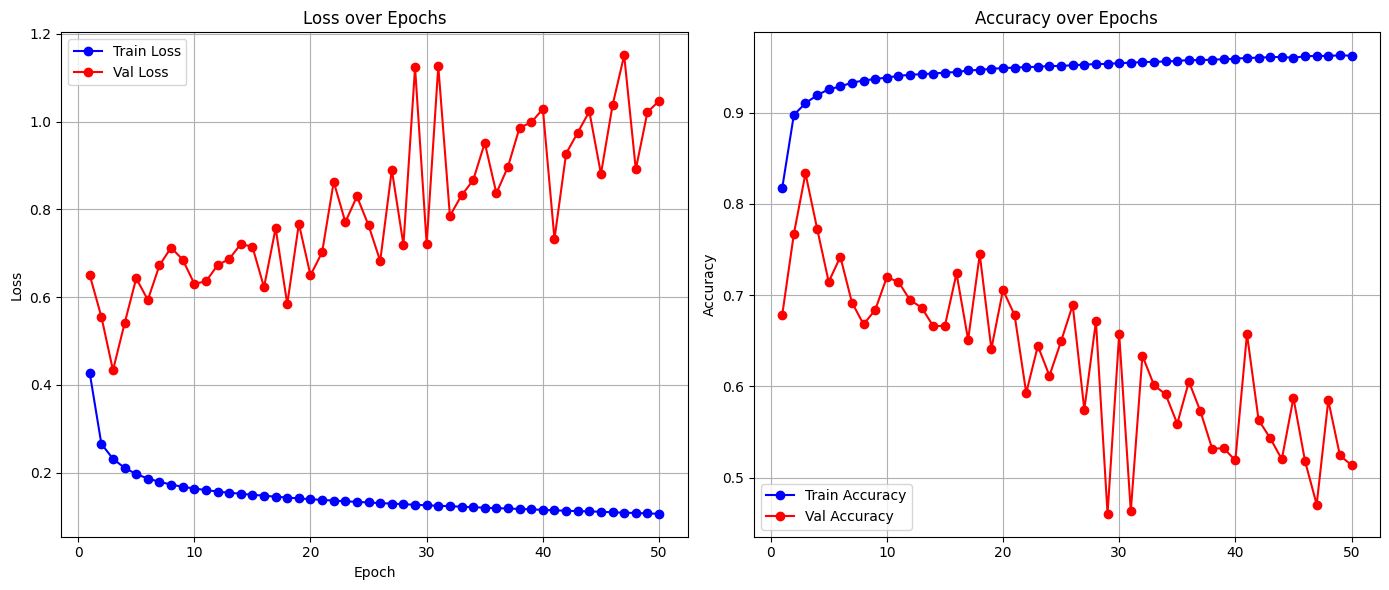

Full model built...
Total execution time: 151.54 seconds
✅ Fold 0 done: Val Loss = 1.0473, Val Acc = 0.5138
Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...
🔍 Inspecting 30-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
Species in validation fold: [np.str_('lythrum_alat

Evaluating: 100%|██████████| 328/328 [00:00<00:00, 777.45it/s]



🔁 Epoch 2/50


Evaluating: 100%|██████████| 328/328 [00:00<00:00, 1109.86it/s]



🔁 Epoch 3/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 328/328 [00:00<00:00, 1128.72it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 328/328 [00:00<00:00, 1078.00it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


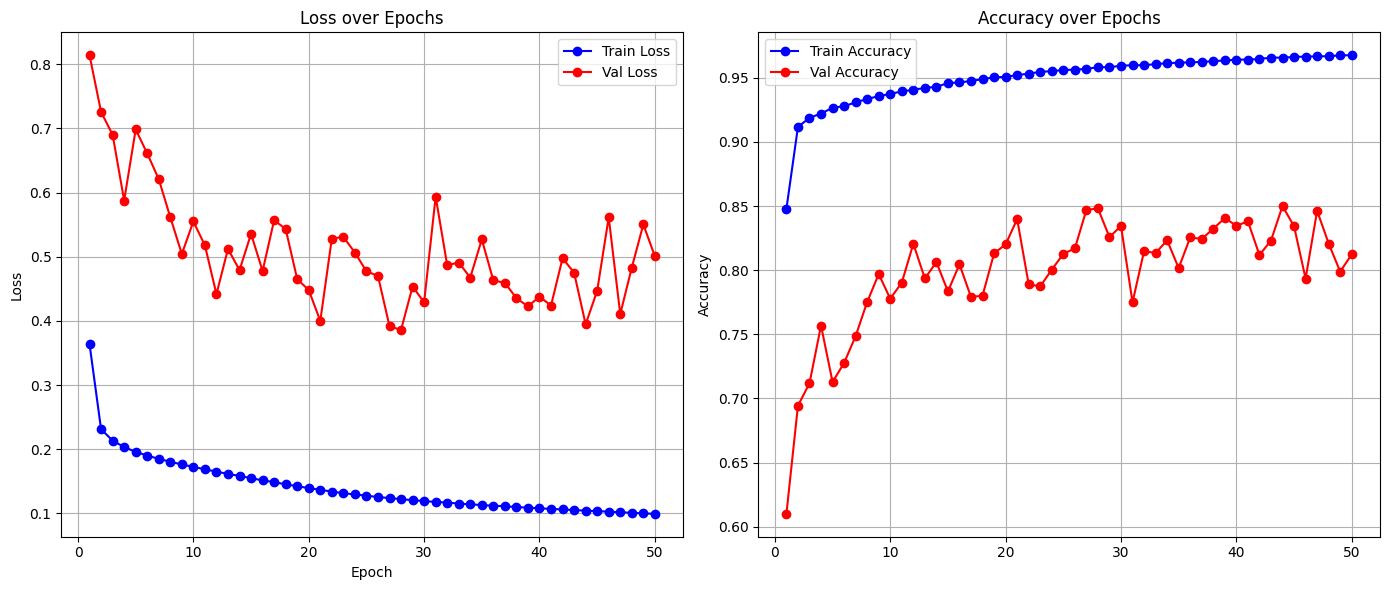

Full model built...
Total execution time: 146.21 seconds
✅ Fold 1 done: Val Loss = 0.5008, Val Acc = 0.8123
Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...
🔍 Inspecting 30-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
Species in validation fold: [np.str_('lythrum_alat

Evaluating: 100%|██████████| 300/300 [00:00<00:00, 777.71it/s]



🔁 Epoch 2/50


Evaluating: 100%|██████████| 300/300 [00:00<00:00, 1081.38it/s]



🔁 Epoch 3/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 300/300 [00:00<00:00, 1068.45it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 300/300 [00:00<00:00, 1092.92it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


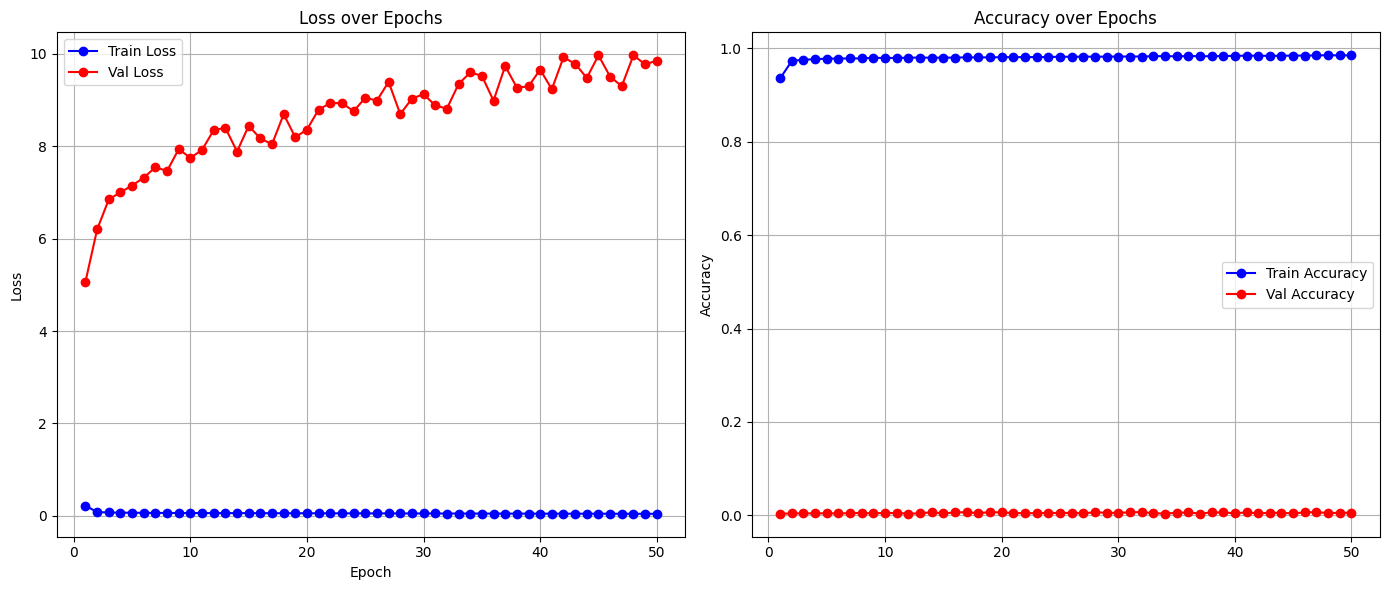

Full model built...
Total execution time: 148.54 seconds
✅ Fold 2 done: Val Loss = 9.8498, Val Acc = 0.0057
Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...
🔍 Inspecting 30-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
Species in validation fold: [np.str_('lythrum_alat

Evaluating: 100%|██████████| 103/103 [00:00<00:00, 1003.97it/s]



🔁 Epoch 2/50


Evaluating: 100%|██████████| 103/103 [00:00<00:00, 1104.37it/s]



🔁 Epoch 3/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 103/103 [00:00<00:00, 1092.84it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 103/103 [00:00<00:00, 1063.31it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


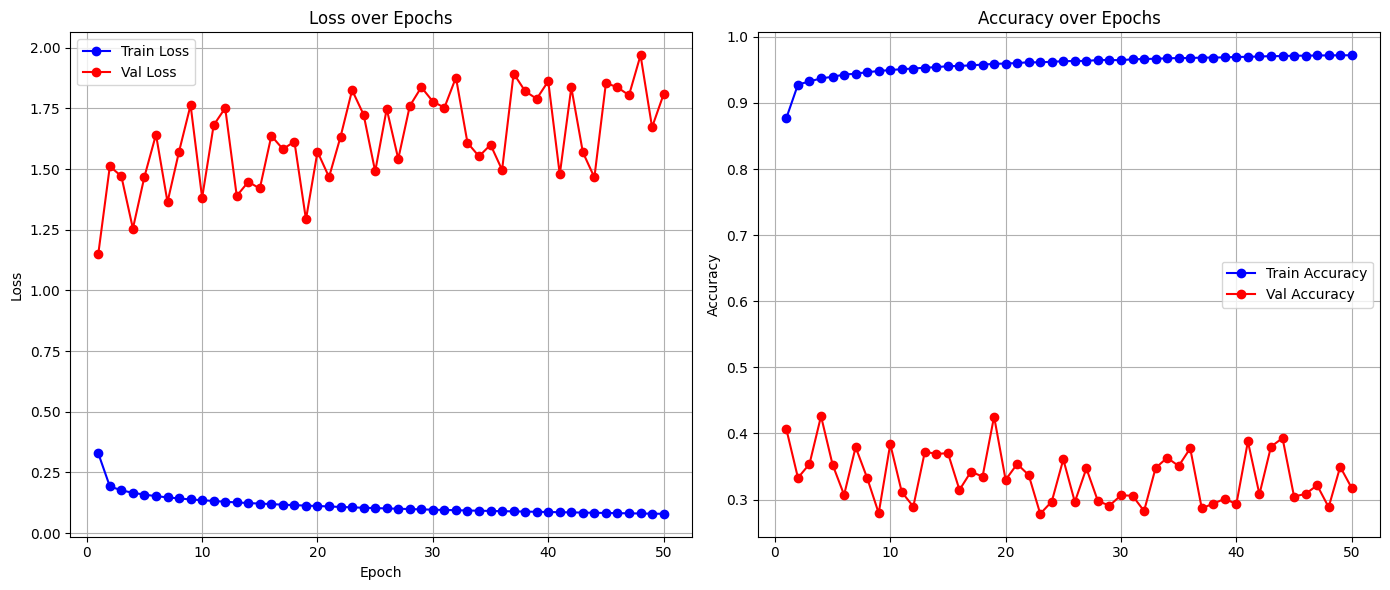

Full model built...
Total execution time: 162.59 seconds
✅ Fold 3 done: Val Loss = 1.8080, Val Acc = 0.3173
Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...
🔍 Inspecting 30-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
Species in validation fold: [np.str_('lythrum_alat

Evaluating: 100%|██████████| 76/76 [00:00<00:00, 980.20it/s]



🔁 Epoch 2/50


Evaluating: 100%|██████████| 76/76 [00:00<00:00, 1036.03it/s]



🔁 Epoch 3/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 76/76 [00:00<00:00, 1040.23it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 76/76 [00:00<00:00, 946.06it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


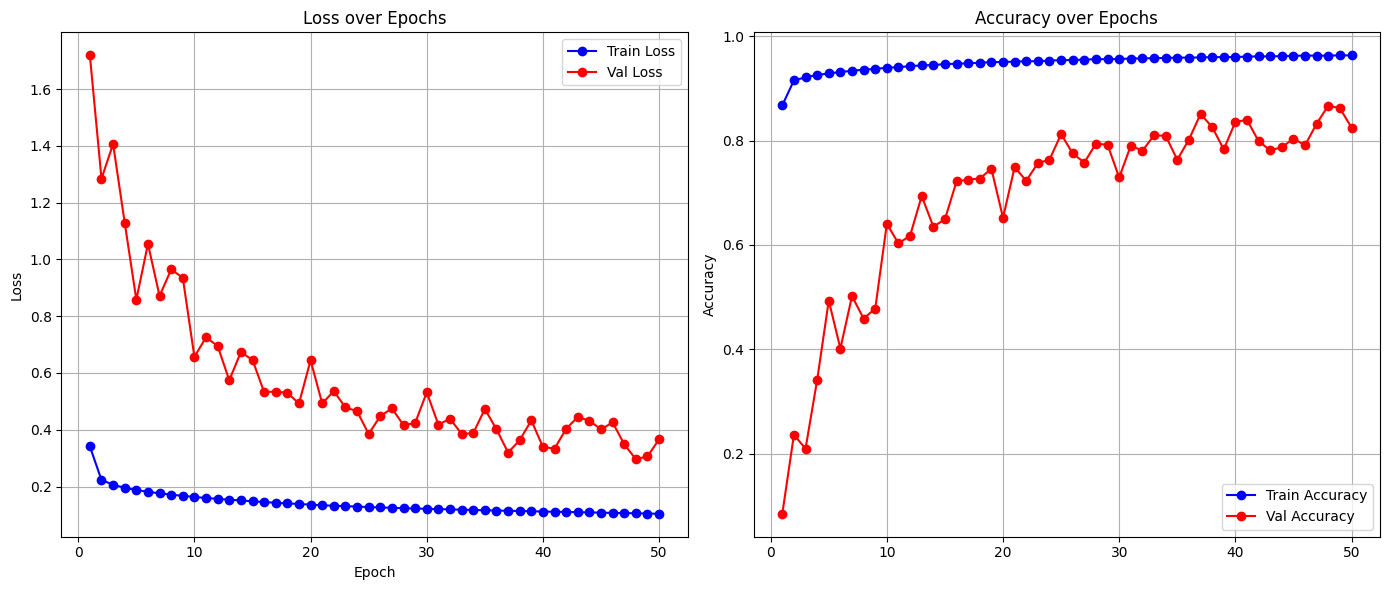

Full model built...
Total execution time: 157.31 seconds
✅ Fold 4 done: Val Loss = 0.3668, Val Acc = 0.8250
Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...
🔍 Inspecting 30-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
Species in validation fold: [np.str_('lythrum_alat

Evaluating: 100%|██████████| 68/68 [00:00<00:00, 874.60it/s]



🔁 Epoch 2/50


Evaluating: 100%|██████████| 68/68 [00:00<00:00, 1034.77it/s]



🔁 Epoch 3/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 68/68 [00:00<00:00, 1008.01it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 68/68 [00:00<00:00, 1007.11it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


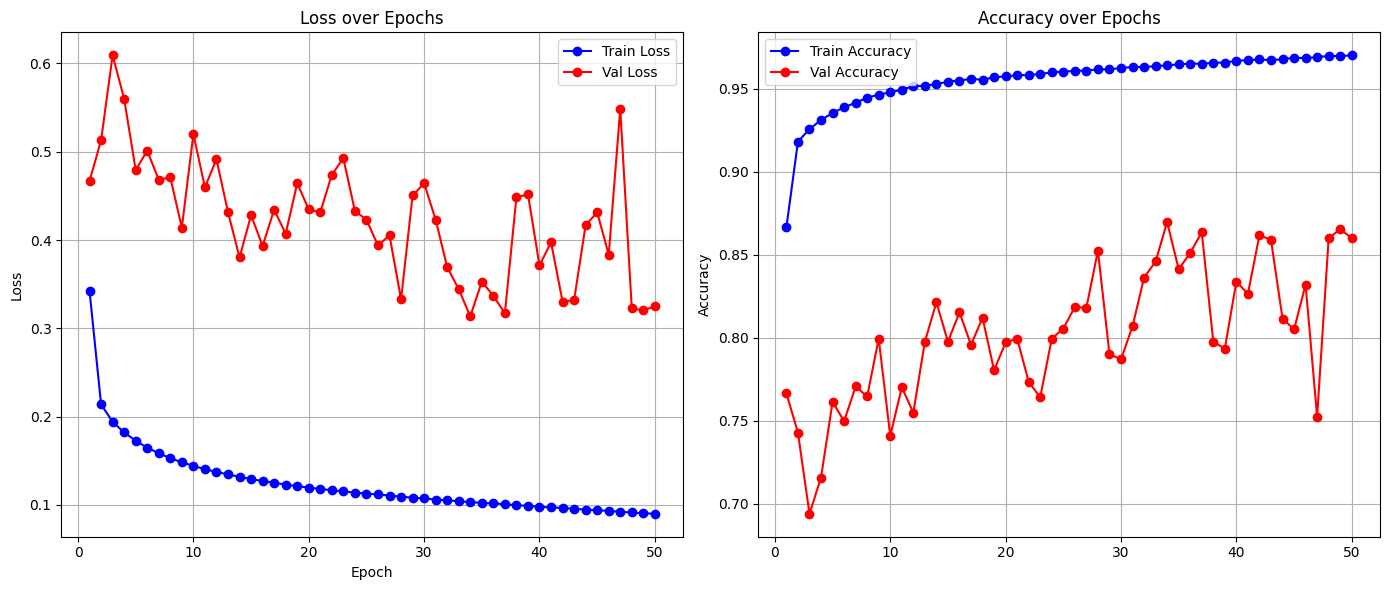

Full model built...
Total execution time: 160.20 seconds
✅ Fold 5 done: Val Loss = 0.3250, Val Acc = 0.8599
Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...
🔍 Inspecting 30-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
Species in validation fold: [np.str_('lythrum_alat

Evaluating: 100%|██████████| 68/68 [00:00<00:00, 393.35it/s]



🔁 Epoch 2/50


Evaluating: 100%|██████████| 68/68 [00:00<00:00, 949.08it/s]



🔁 Epoch 3/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 68/68 [00:00<00:00, 975.15it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 68/68 [00:00<00:00, 939.79it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


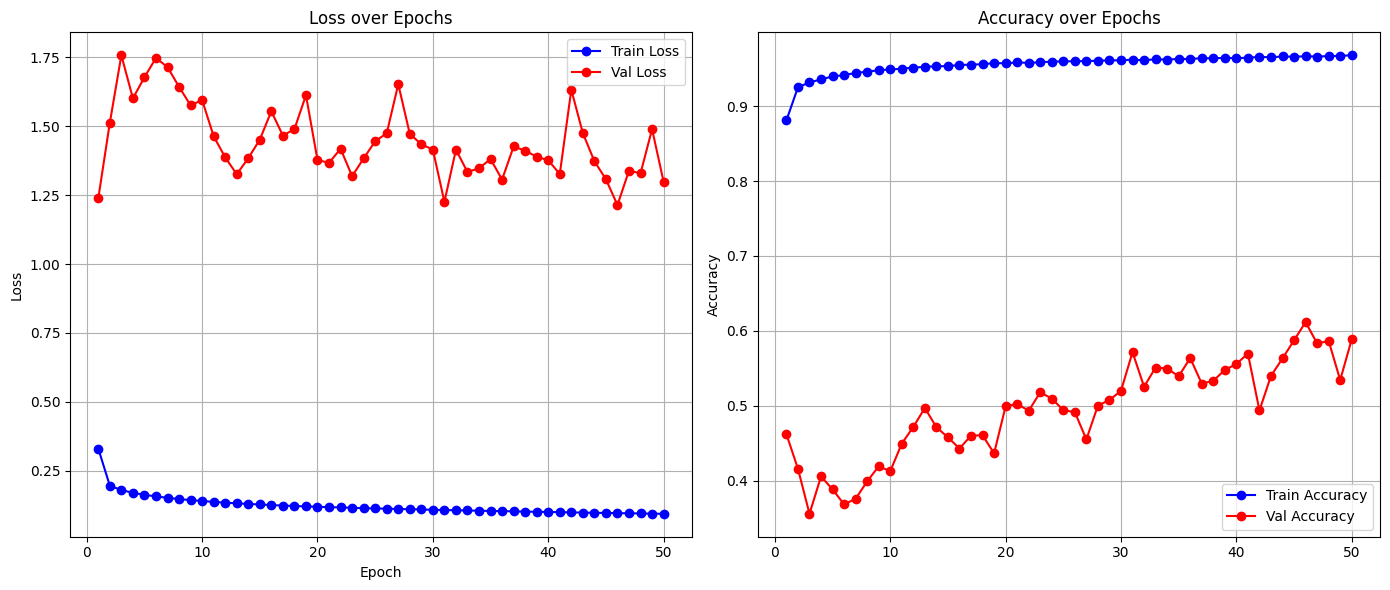

Full model built...
Total execution time: 160.56 seconds
✅ Fold 6 done: Val Loss = 1.2981, Val Acc = 0.5888
Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...
🔍 Inspecting 30-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
Species in validation fold: [np.str_('lythrum_alat

Evaluating: 100%|██████████| 14/14 [00:00<00:00, 566.36it/s]



🔁 Epoch 2/50


Evaluating: 100%|██████████| 14/14 [00:00<00:00, 828.61it/s]



🔁 Epoch 3/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 14/14 [00:00<00:00, 810.64it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 14/14 [00:00<00:00, 737.30it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


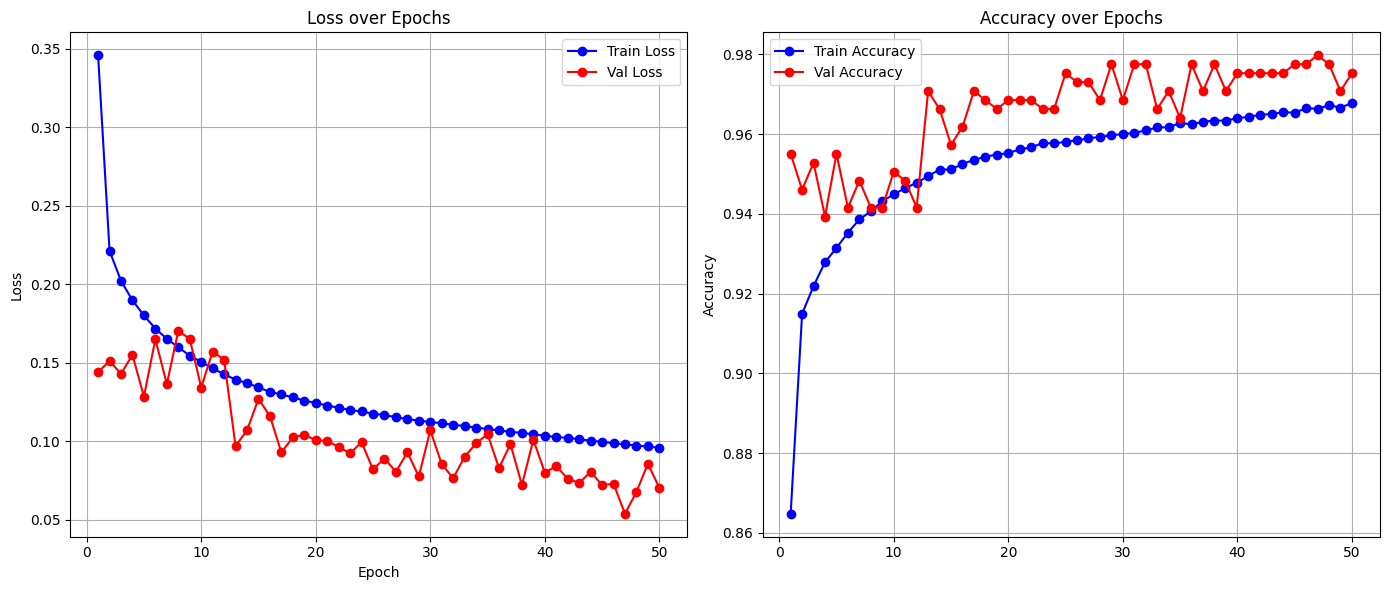

Full model built...
Total execution time: 163.22 seconds
✅ Fold 7 done: Val Loss = 0.0703, Val Acc = 0.9753
Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...
🔍 Inspecting 30-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
Species in validation fold: [np.str_('lythrum_alat

Evaluating: 100%|██████████| 12/12 [00:00<00:00, 646.20it/s]



🔁 Epoch 2/50


Evaluating: 100%|██████████| 12/12 [00:00<00:00, 864.58it/s]



🔁 Epoch 3/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 12/12 [00:00<00:00, 828.48it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 12/12 [00:00<00:00, 662.49it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


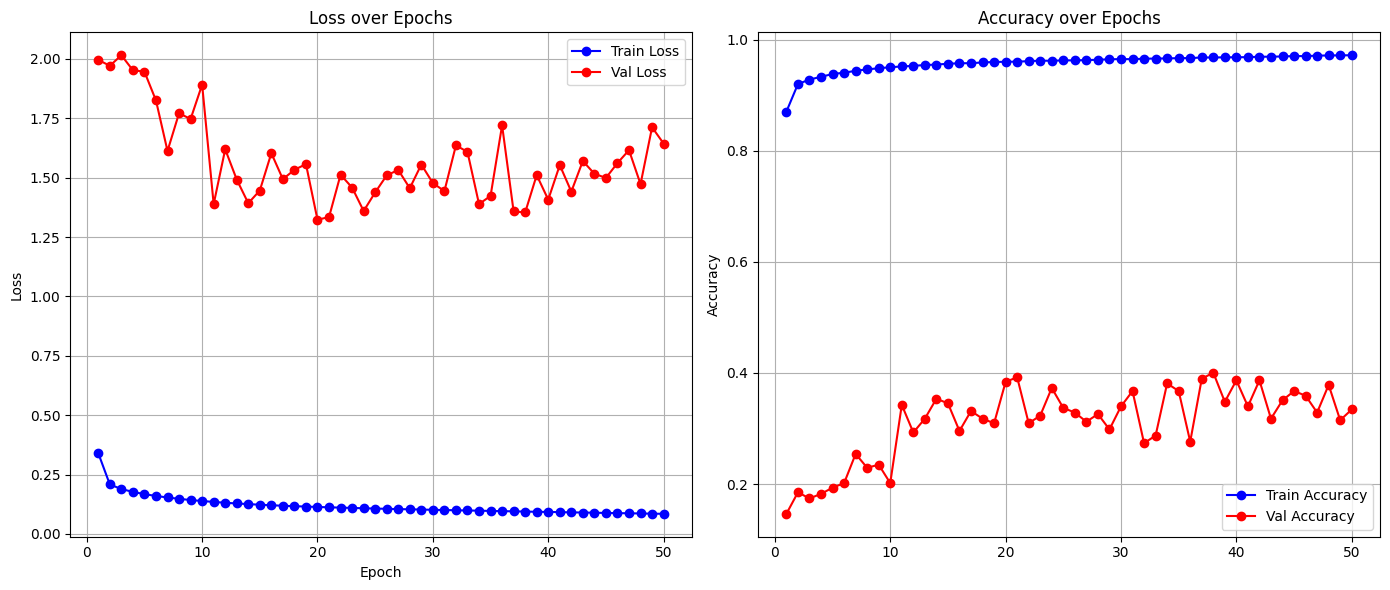

Full model built...
Total execution time: 166.48 seconds
✅ Fold 8 done: Val Loss = 1.6436, Val Acc = 0.3343
Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...
🔍 Inspecting 30-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
Species in validation fold: [np.str_('lythrum_alat

Evaluating: 100%|██████████| 11/11 [00:00<00:00, 719.11it/s]



🔁 Epoch 2/50


Evaluating: 100%|██████████| 11/11 [00:00<00:00, 801.05it/s]



🔁 Epoch 3/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 11/11 [00:00<00:00, 819.65it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 11/11 [00:00<00:00, 786.62it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


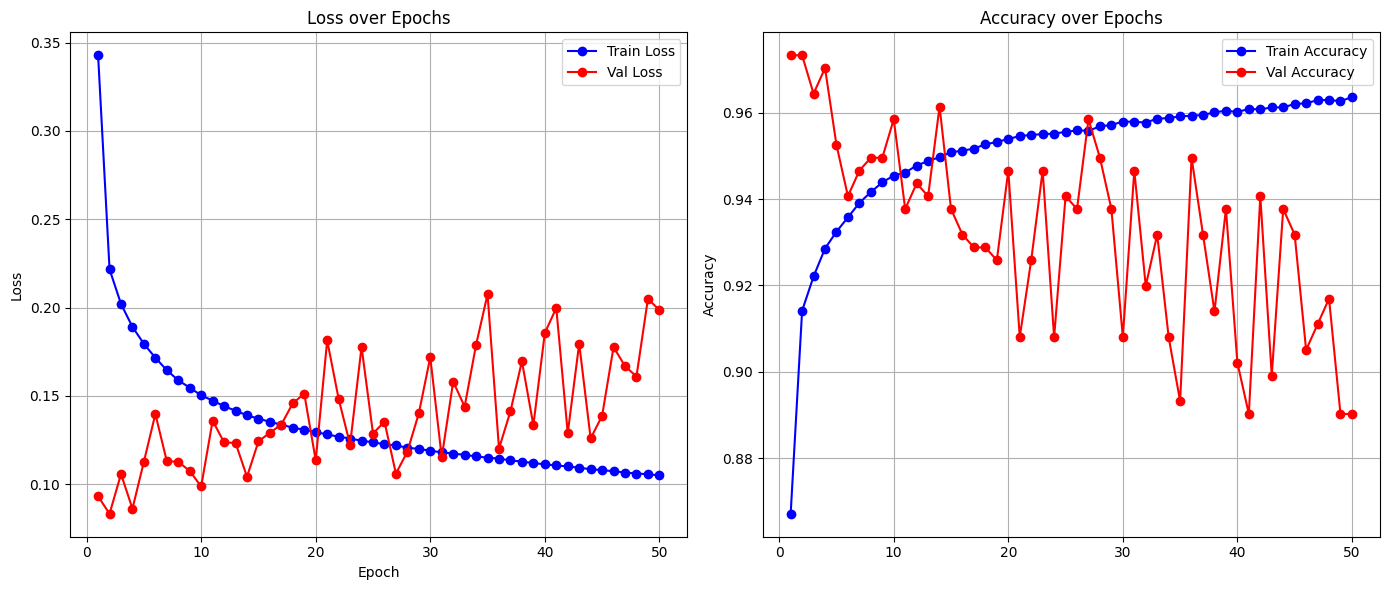

Full model built...
Total execution time: 165.26 seconds
✅ Fold 9 done: Val Loss = 0.1986, Val Acc = 0.8902
Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...
🔍 Inspecting 30-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
Species in validation fold: [np.str_('lythrum_alat

Evaluating: 100%|██████████| 8/8 [00:00<00:00, 678.29it/s]



🔁 Epoch 2/50


Evaluating: 100%|██████████| 8/8 [00:00<00:00, 760.85it/s]



🔁 Epoch 3/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 8/8 [00:00<00:00, 753.32it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 8/8 [00:00<00:00, 508.20it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


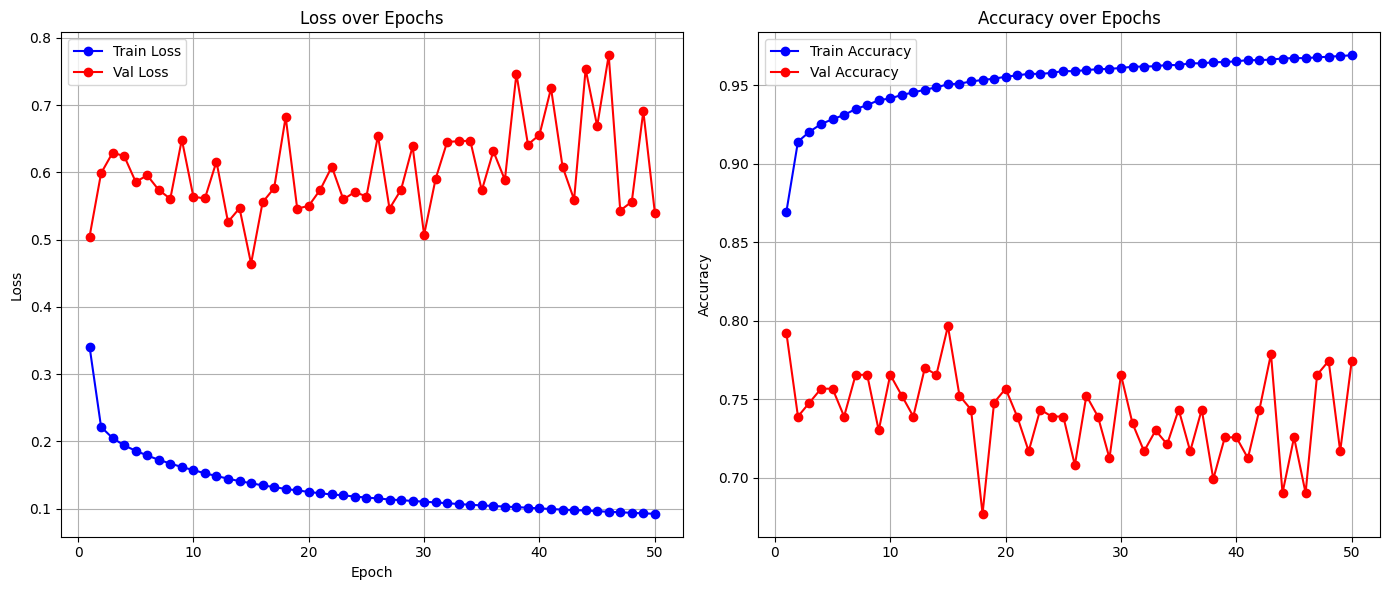

Full model built...
Total execution time: 165.92 seconds
✅ Fold 10 done: Val Loss = 0.5398, Val Acc = 0.7743
Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...
🔍 Inspecting 30-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
Species in validation fold: [np.str_('lythrum_ala

Evaluating: 100%|██████████| 5/5 [00:00<00:00, 722.41it/s]



🔁 Epoch 2/50


Evaluating: 100%|██████████| 5/5 [00:00<00:00, 615.63it/s]



🔁 Epoch 3/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 5/5 [00:00<00:00, 678.60it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 5/5 [00:00<00:00, 742.33it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


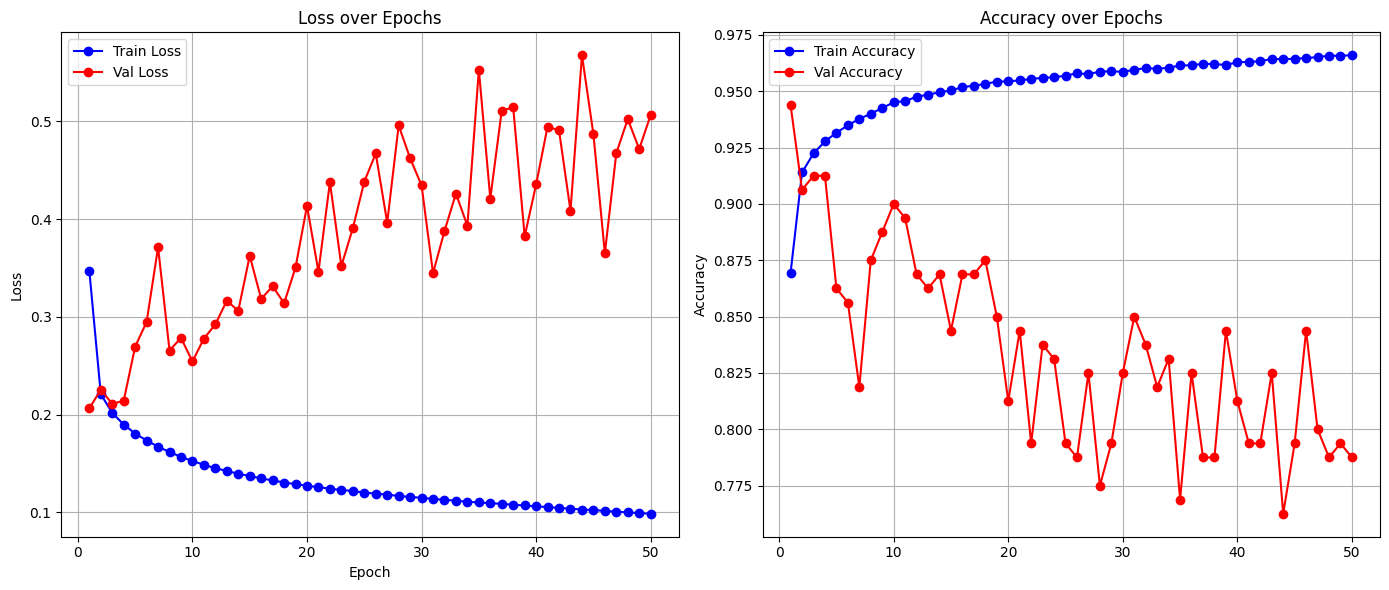

Full model built...
Total execution time: 169.35 seconds
✅ Fold 11 done: Val Loss = 0.5066, Val Acc = 0.7875
Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...
🔍 Inspecting 30-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
Species in validation fold: [np.str_('lythrum_ala

Evaluating: 100%|██████████| 5/5 [00:00<00:00, 647.63it/s]



🔁 Epoch 2/50


Evaluating: 100%|██████████| 5/5 [00:00<00:00, 684.38it/s]



🔁 Epoch 3/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 5/5 [00:00<00:00, 735.97it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 5/5 [00:00<00:00, 763.68it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


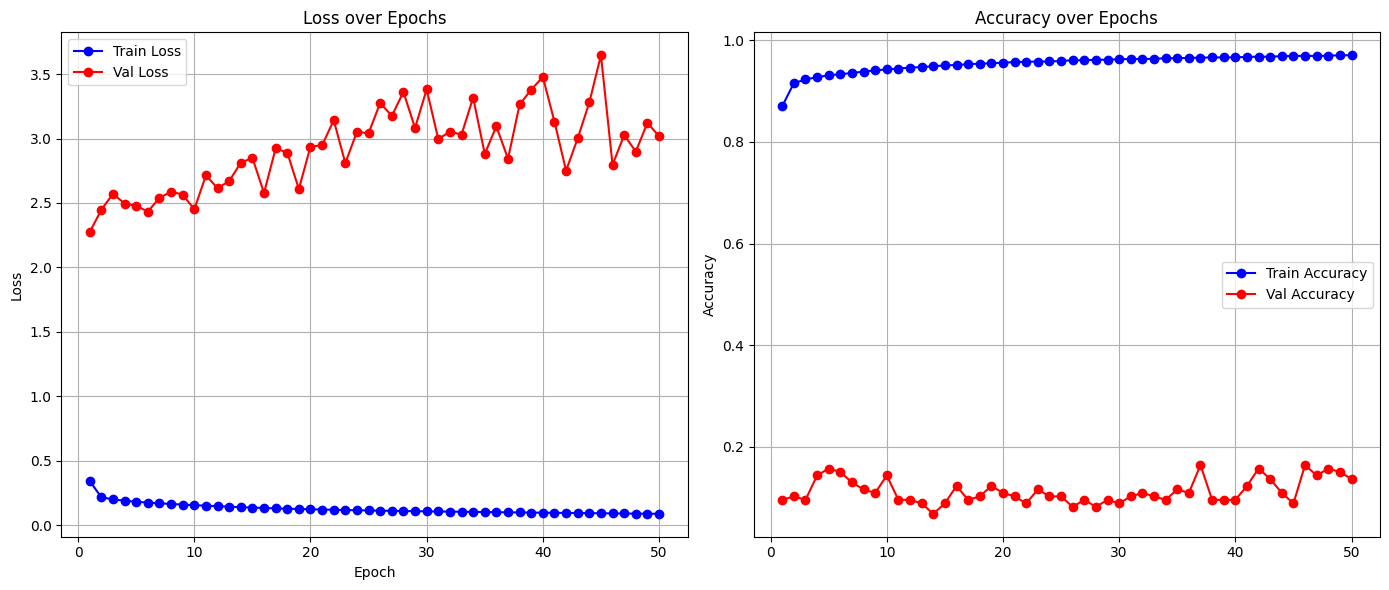

Full model built...
Total execution time: 170.25 seconds
✅ Fold 12 done: Val Loss = 3.0186, Val Acc = 0.1370
Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...
🔍 Inspecting 30-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
Species in validation fold: [np.str_('lythrum_ala

Evaluating: 100%|██████████| 4/4 [00:00<00:00, 682.08it/s]



🔁 Epoch 2/50


Evaluating: 100%|██████████| 4/4 [00:00<00:00, 561.73it/s]



🔁 Epoch 3/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 4/4 [00:00<00:00, 950.60it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 4/4 [00:00<00:00, 615.52it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


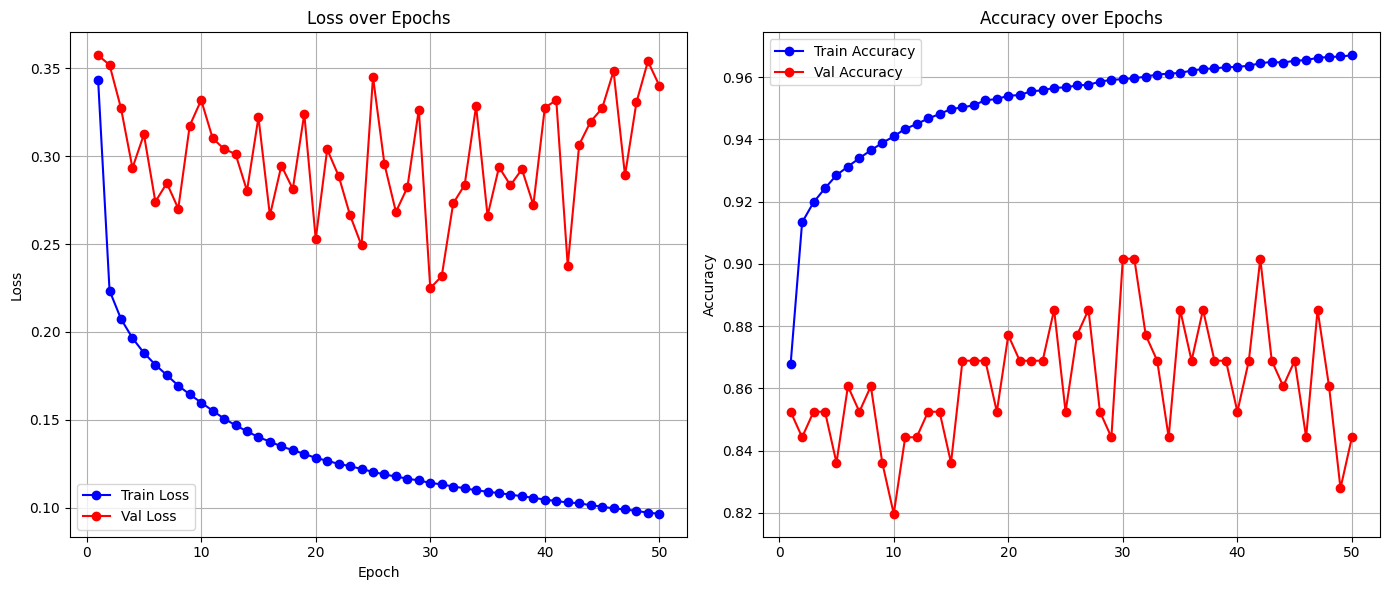

Full model built...
Total execution time: 169.06 seconds
✅ Fold 13 done: Val Loss = 0.3401, Val Acc = 0.8443
Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...
🔍 Inspecting 30-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
Species in validation fold: [np.str_('lythrum_ala

Evaluating: 100%|██████████| 3/3 [00:00<00:00, 521.33it/s]



🔁 Epoch 2/50


Evaluating: 100%|██████████| 3/3 [00:00<00:00, 783.59it/s]



🔁 Epoch 3/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 3/3 [00:00<00:00, 805.31it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 3/3 [00:00<00:00, 738.95it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


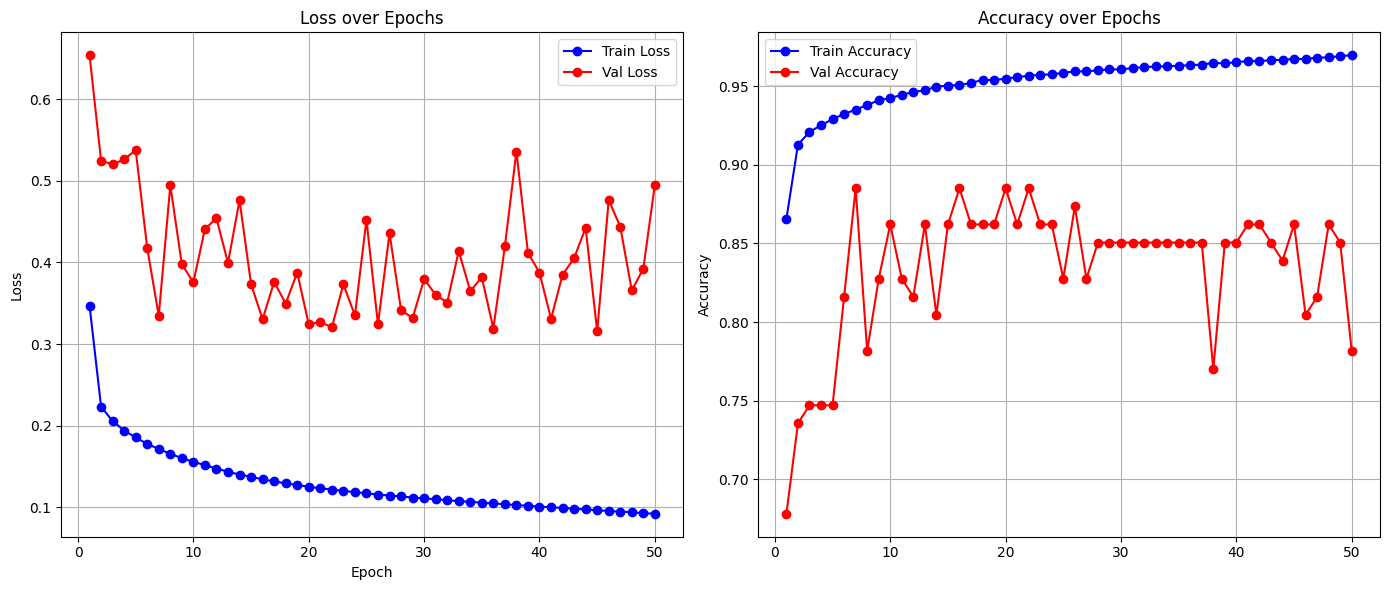

Full model built...
Total execution time: 171.12 seconds
✅ Fold 14 done: Val Loss = 0.4955, Val Acc = 0.7816
Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...
🔍 Inspecting 30-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
Species in validation fold: [np.str_('lythrum_ala

Evaluating: 100%|██████████| 3/3 [00:00<00:00, 760.89it/s]



🔁 Epoch 2/50


Evaluating: 100%|██████████| 3/3 [00:00<00:00, 675.92it/s]



🔁 Epoch 3/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 3/3 [00:00<00:00, 685.49it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 3/3 [00:00<00:00, 754.42it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


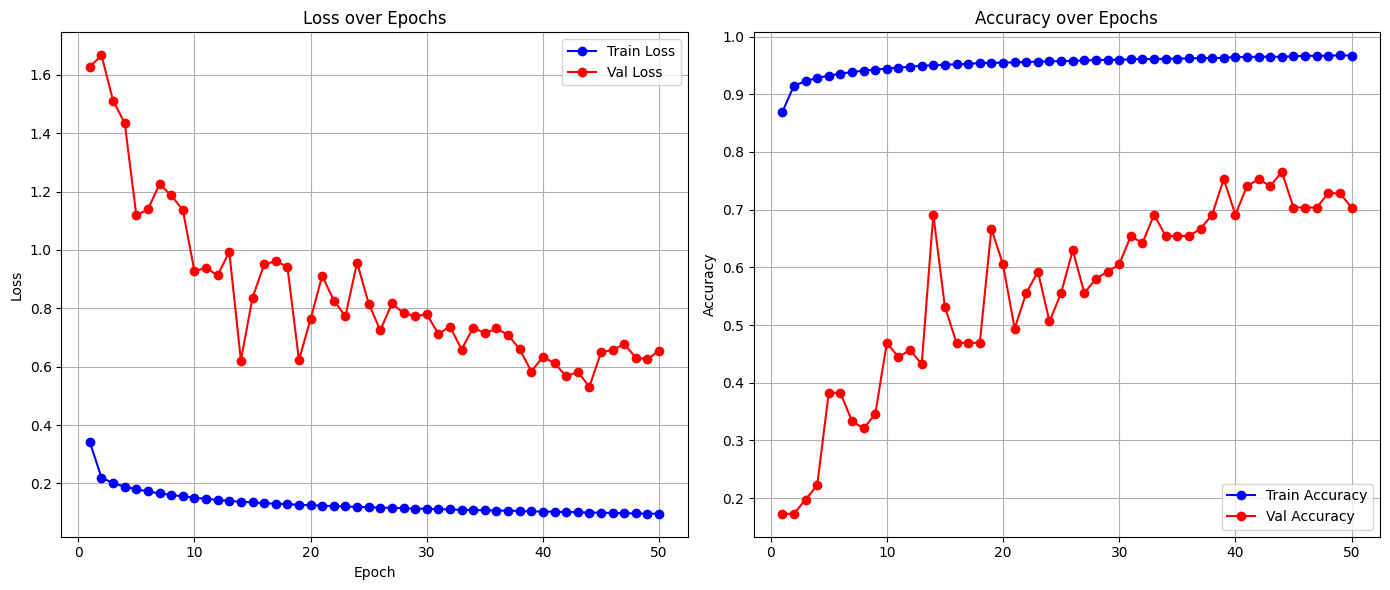

Full model built...
Total execution time: 172.96 seconds
✅ Fold 15 done: Val Loss = 0.6551, Val Acc = 0.7037
Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...
🔍 Inspecting 30-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
Species in validation fold: [np.str_('lythrum_ala

Evaluating: 100%|██████████| 2/2 [00:00<00:00, 617.58it/s]



🔁 Epoch 2/50


Evaluating: 100%|██████████| 2/2 [00:00<00:00, 790.41it/s]



🔁 Epoch 3/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 2/2 [00:00<00:00, 657.31it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 2/2 [00:00<00:00, 766.71it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


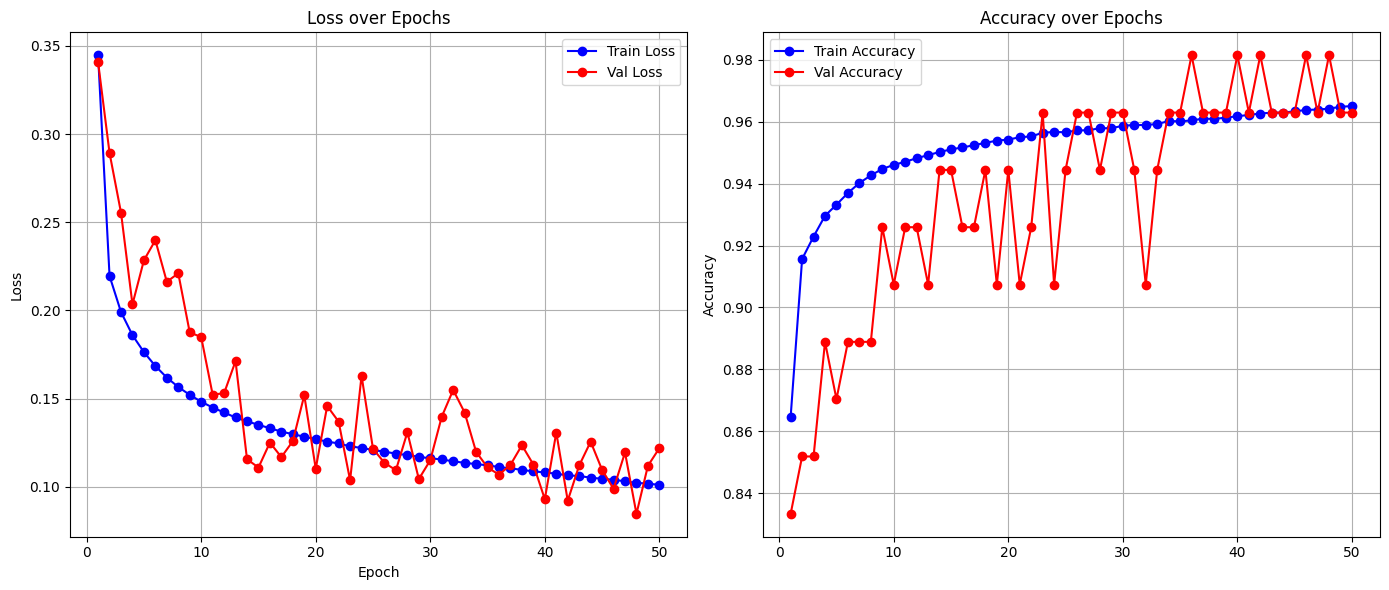

Full model built...
Total execution time: 172.43 seconds
✅ Fold 16 done: Val Loss = 0.1219, Val Acc = 0.9630
Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...
🔍 Inspecting 30-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
Species in validation fold: [np.str_('lythrum_ala

Evaluating: 100%|██████████| 2/2 [00:00<00:00, 813.01it/s]



🔁 Epoch 2/50


Evaluating: 100%|██████████| 2/2 [00:00<00:00, 544.50it/s]



🔁 Epoch 3/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 2/2 [00:00<00:00, 875.64it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 2/2 [00:00<00:00, 662.14it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


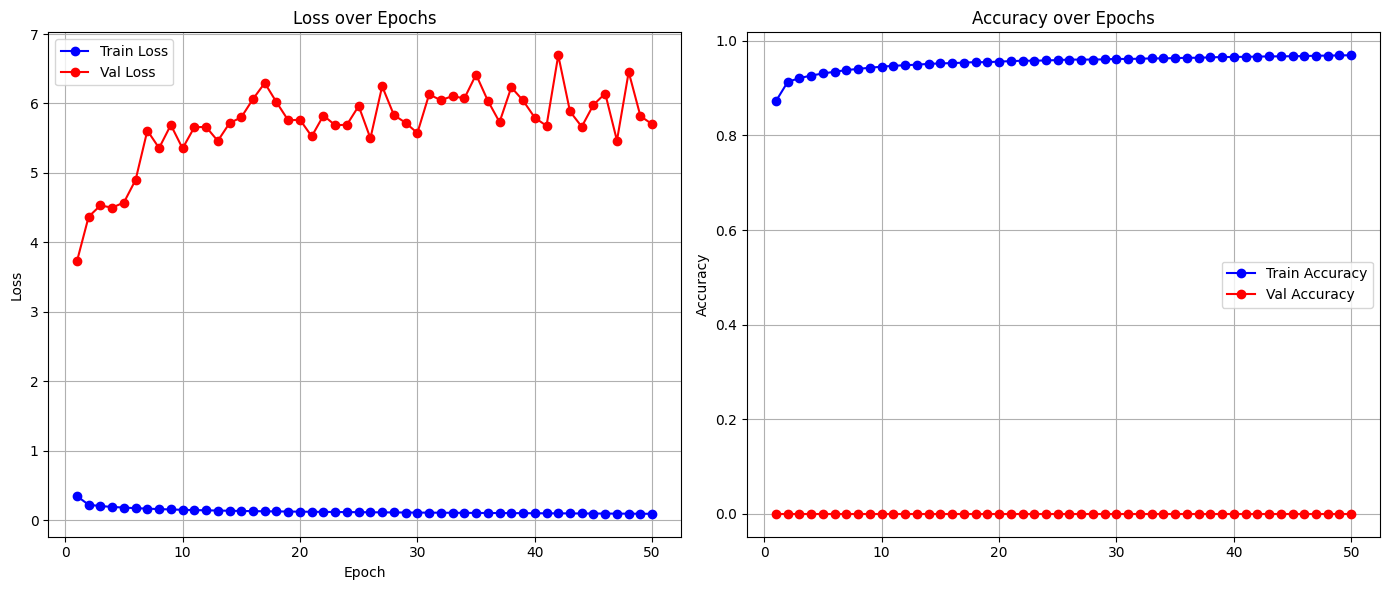

Full model built...
Total execution time: 172.05 seconds
✅ Fold 17 done: Val Loss = 5.7014, Val Acc = 0.0000
Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...
🔍 Inspecting 30-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
Species in validation fold: [np.str_('lythrum_ala

Evaluating: 100%|██████████| 1/1 [00:00<00:00, 436.32it/s]



🔁 Epoch 2/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 555.54it/s]



🔁 Epoch 3/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 473.24it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 600.13it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


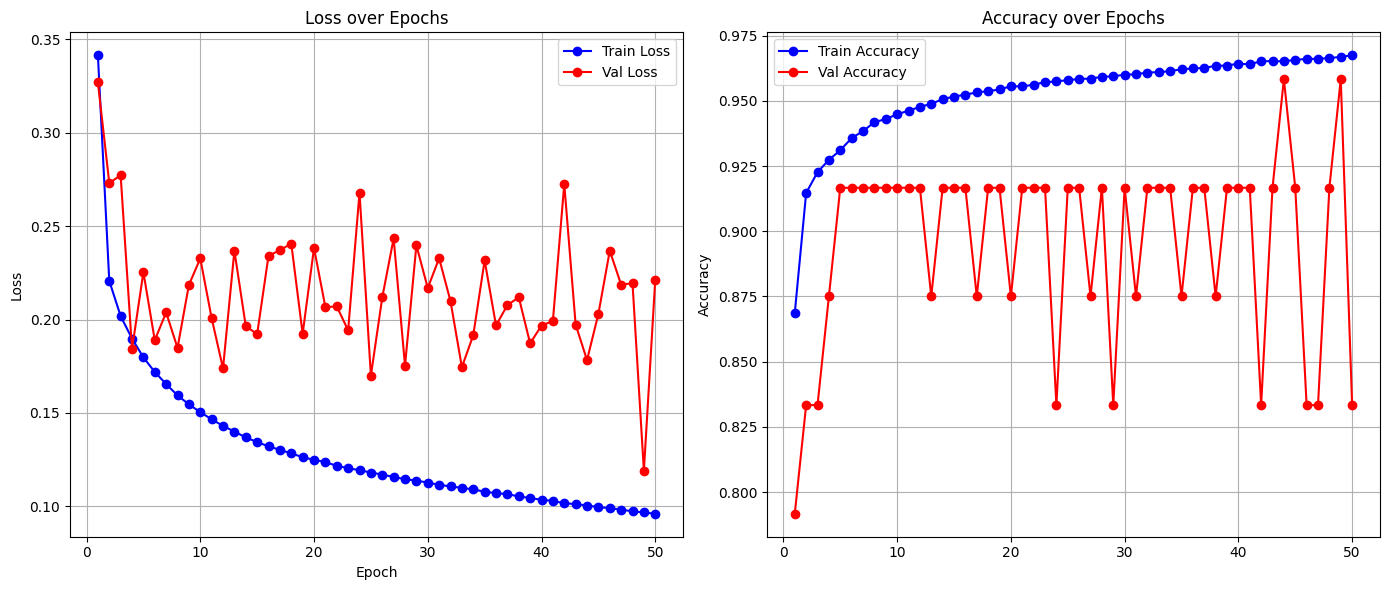

Full model built...
Total execution time: 172.23 seconds
✅ Fold 18 done: Val Loss = 0.2213, Val Acc = 0.8333
Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...
🔍 Inspecting 30-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
Species in validation fold: [np.str_('lythrum_ala

Evaluating: 100%|██████████| 1/1 [00:00<00:00, 697.19it/s]



🔁 Epoch 2/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 726.29it/s]



🔁 Epoch 3/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 711.38it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 708.86it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


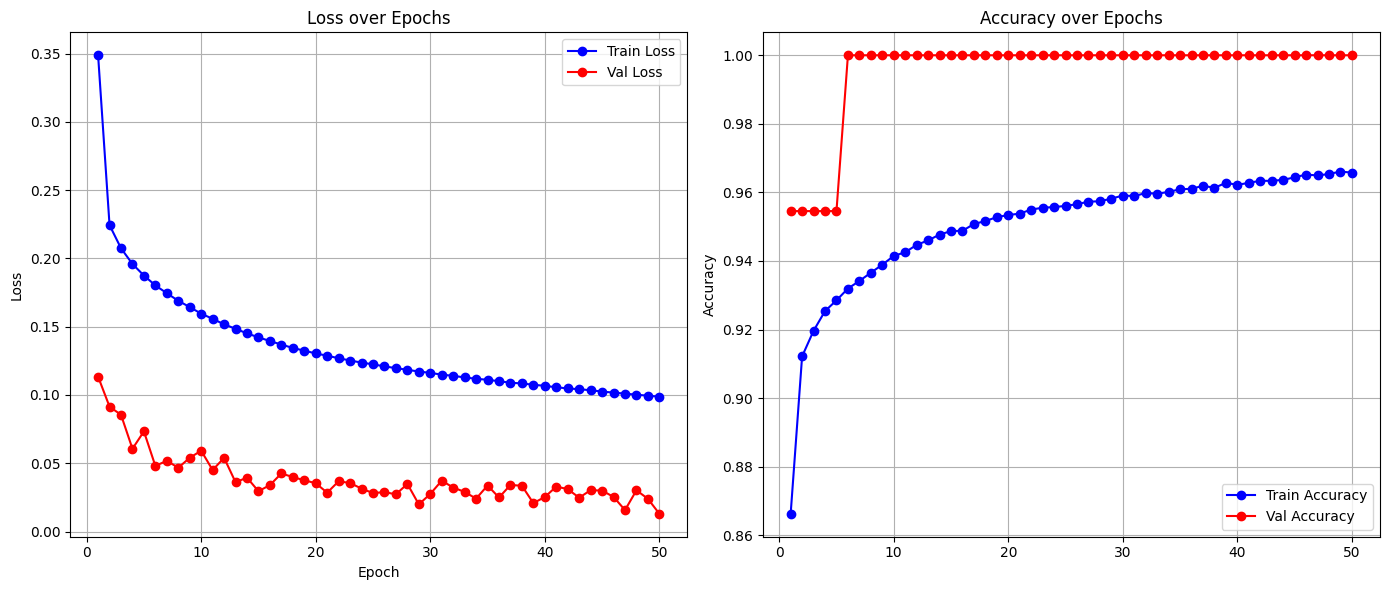

Full model built...
Total execution time: 173.37 seconds
✅ Fold 19 done: Val Loss = 0.0130, Val Acc = 1.0000
Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...
🔍 Inspecting 30-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
Species in validation fold: [np.str_('lythrum_ala

Evaluating: 100%|██████████| 1/1 [00:00<00:00, 632.72it/s]



🔁 Epoch 2/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 716.73it/s]



🔁 Epoch 3/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 732.63it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 761.49it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


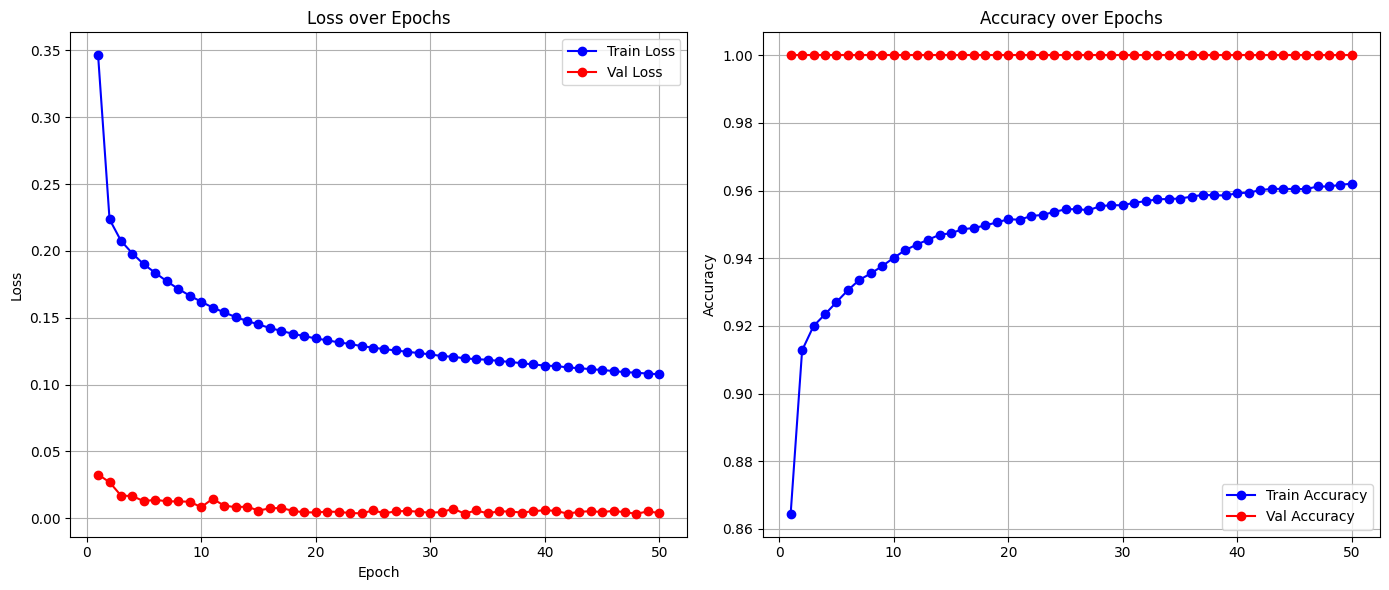

Full model built...
Total execution time: 174.75 seconds
✅ Fold 20 done: Val Loss = 0.0039, Val Acc = 1.0000
Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...
🔍 Inspecting 30-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
Species in validation fold: [np.str_('lythrum_ala

Evaluating: 100%|██████████| 1/1 [00:00<00:00, 803.51it/s]



🔁 Epoch 2/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 649.57it/s]



🔁 Epoch 3/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 548.28it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 676.72it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


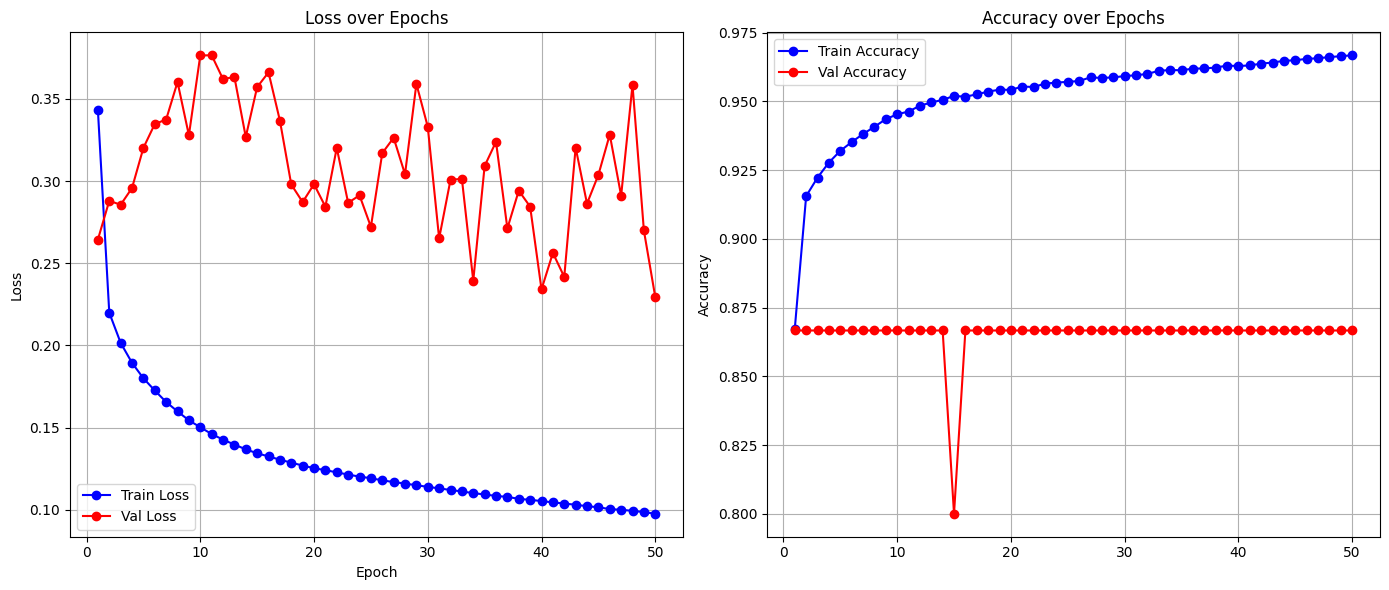

Full model built...
Total execution time: 175.67 seconds
✅ Fold 21 done: Val Loss = 0.2295, Val Acc = 0.8667
Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...
🔍 Inspecting 30-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
Species in validation fold: [np.str_('lythrum_ala

Evaluating: 100%|██████████| 1/1 [00:00<00:00, 596.21it/s]



🔁 Epoch 2/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 676.50it/s]



🔁 Epoch 3/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 745.26it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 804.12it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


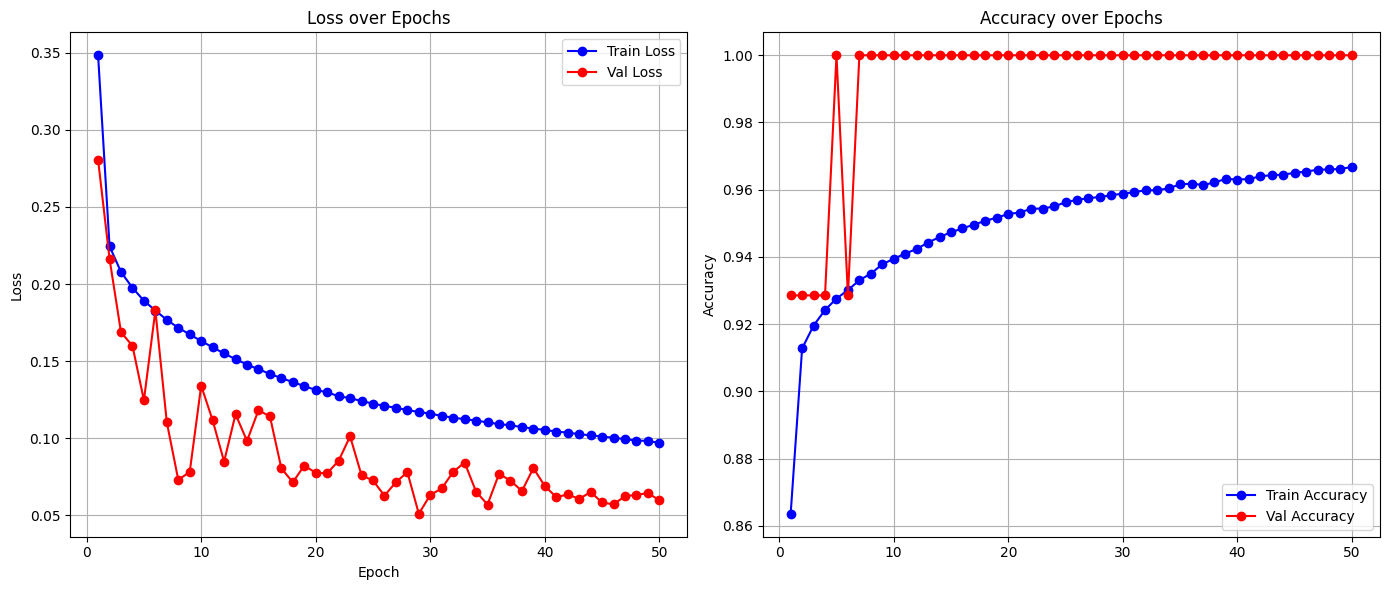

Full model built...
Total execution time: 175.64 seconds
✅ Fold 22 done: Val Loss = 0.0598, Val Acc = 1.0000
Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...
🔍 Inspecting 30-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
Species in validation fold: [np.str_('lythrum_ala

Evaluating: 100%|██████████| 1/1 [00:00<00:00, 312.33it/s]



🔁 Epoch 2/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 693.39it/s]



🔁 Epoch 3/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 745.39it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 604.02it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


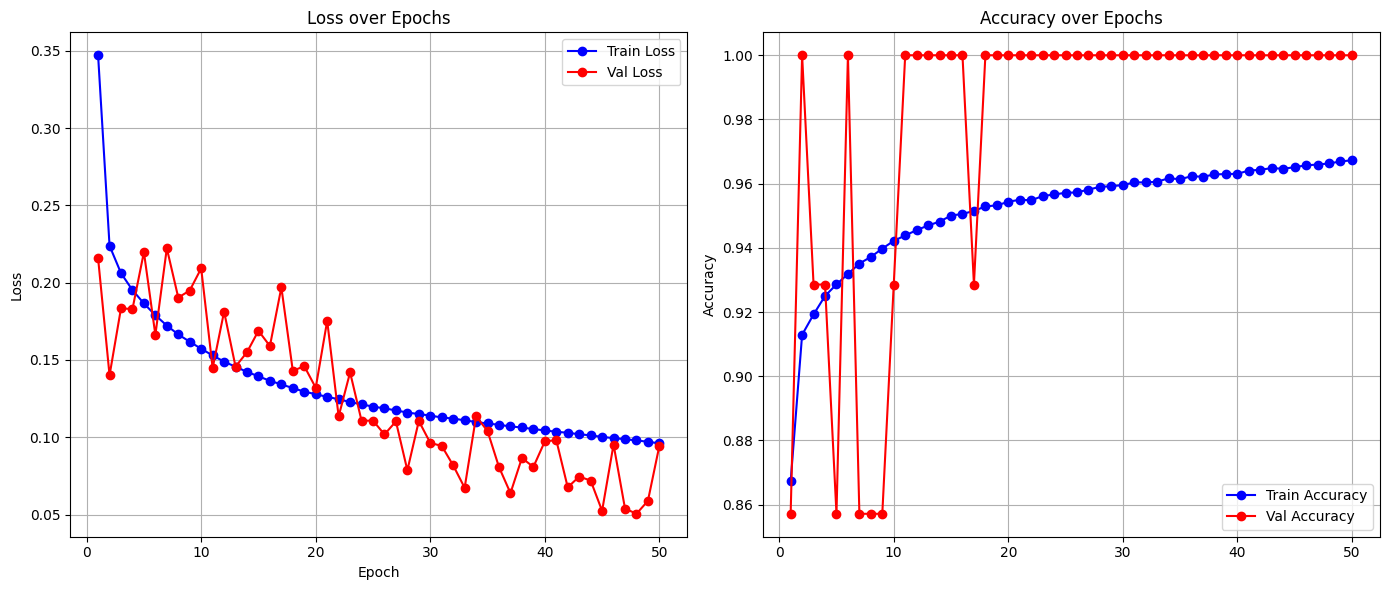

Full model built...
Total execution time: 177.39 seconds
✅ Fold 23 done: Val Loss = 0.0945, Val Acc = 1.0000
Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...
🔍 Inspecting 30-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
Species in validation fold: [np.str_('lythrum_ala

Evaluating: 100%|██████████| 1/1 [00:00<00:00, 630.25it/s]



🔁 Epoch 2/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 493.22it/s]



🔁 Epoch 3/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 794.53it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 686.69it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


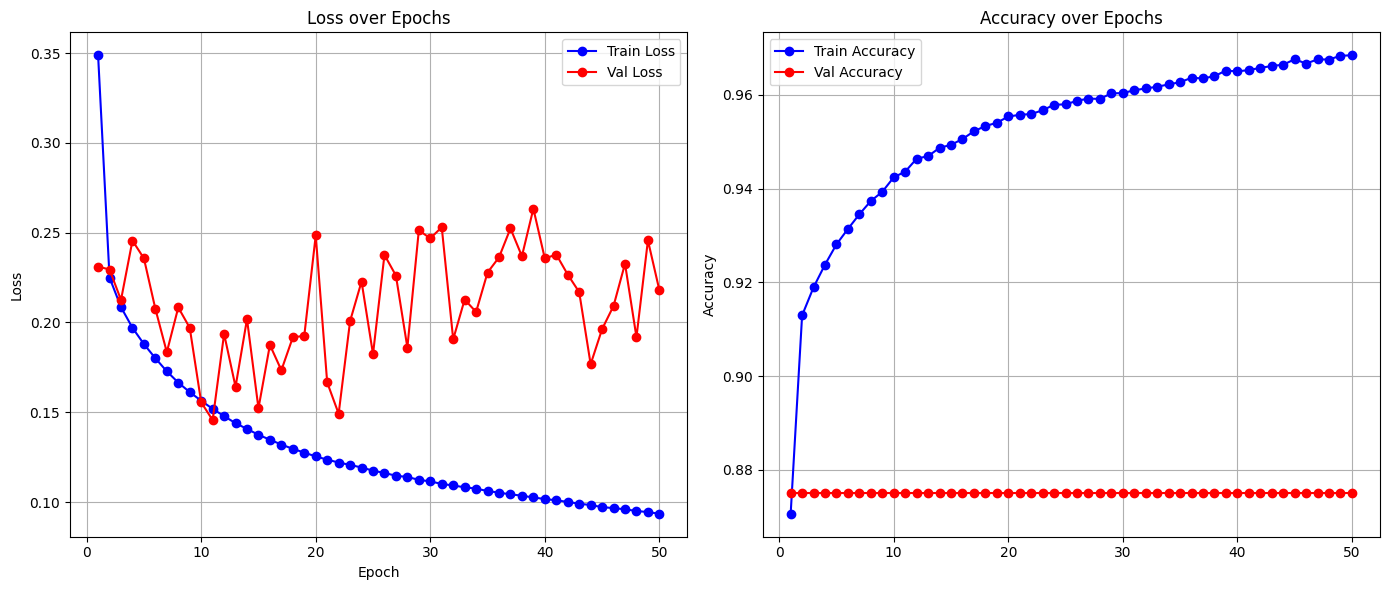

Full model built...
Total execution time: 176.53 seconds
✅ Fold 24 done: Val Loss = 0.2180, Val Acc = 0.8750
Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...
🔍 Inspecting 30-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
Species in validation fold: [np.str_('lythrum_ala

Evaluating: 100%|██████████| 1/1 [00:00<00:00, 568.95it/s]



🔁 Epoch 2/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 894.31it/s]



🔁 Epoch 3/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 420.69it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 583.43it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


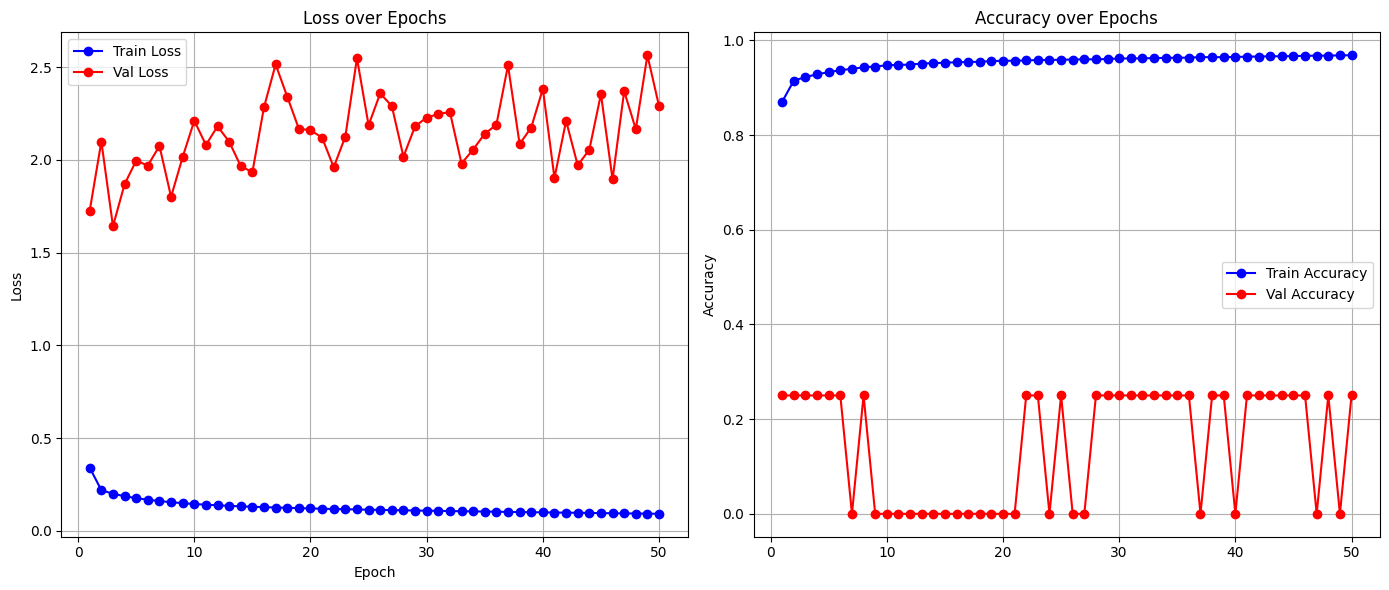

Full model built...
Total execution time: 179.39 seconds
✅ Fold 25 done: Val Loss = 2.2907, Val Acc = 0.2500
Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...
🔍 Inspecting 30-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
Species in validation fold: [np.str_('lythrum_ala

Evaluating: 100%|██████████| 1/1 [00:00<00:00, 931.03it/s]



🔁 Epoch 2/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 281.69it/s]



🔁 Epoch 3/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 589.25it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 360.89it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


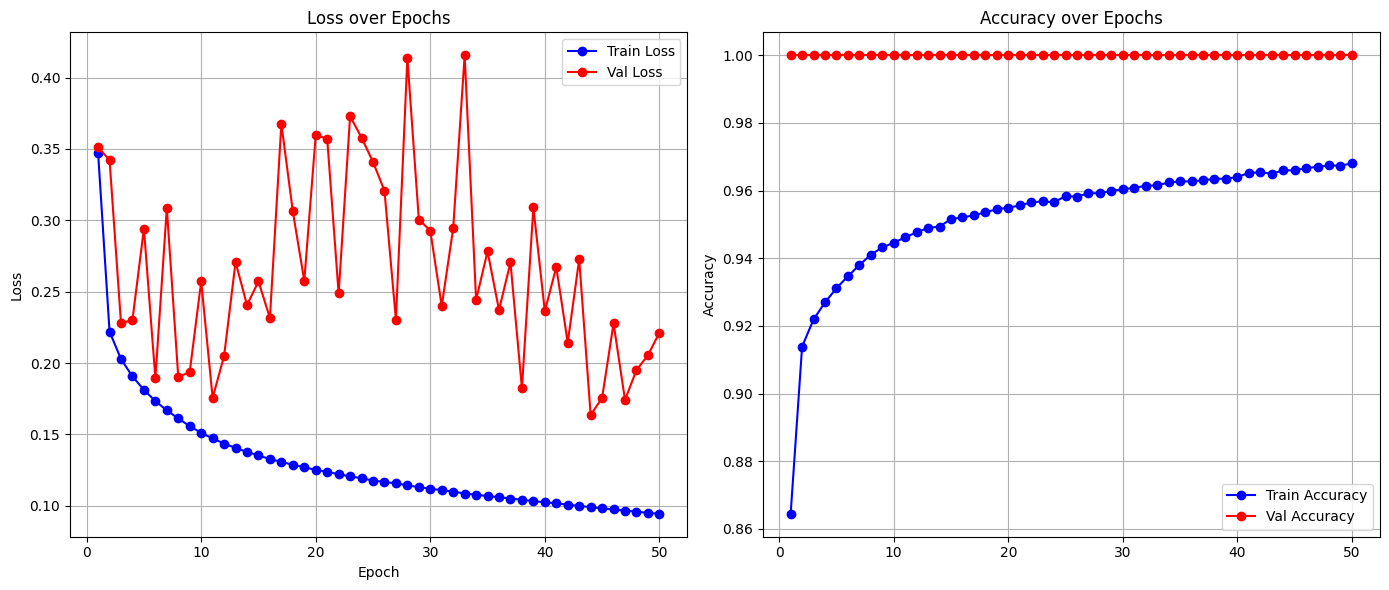

Full model built...
Total execution time: 178.09 seconds
✅ Fold 26 done: Val Loss = 0.2213, Val Acc = 1.0000
Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...
🔍 Inspecting 30-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
Species in validation fold: [np.str_('lythrum_ala

Evaluating: 100%|██████████| 1/1 [00:00<00:00, 899.87it/s]



🔁 Epoch 2/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 782.52it/s]



🔁 Epoch 3/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 644.58it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 650.99it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


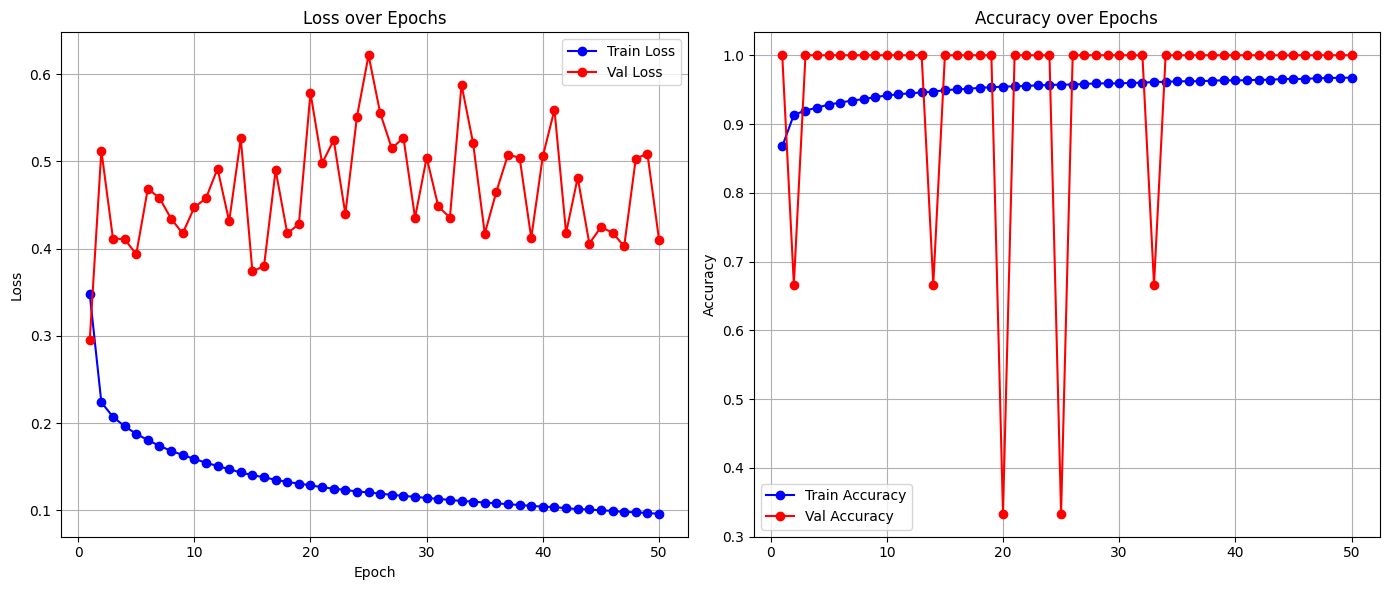

Full model built...
Total execution time: 181.38 seconds
✅ Fold 27 done: Val Loss = 0.4102, Val Acc = 1.0000
Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...
🔍 Inspecting 30-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
Species in validation fold: [np.str_('lythrum_ala

Evaluating: 100%|██████████| 1/1 [00:00<00:00, 375.56it/s]



🔁 Epoch 2/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 809.24it/s]



🔁 Epoch 3/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 567.95it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 947.01it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


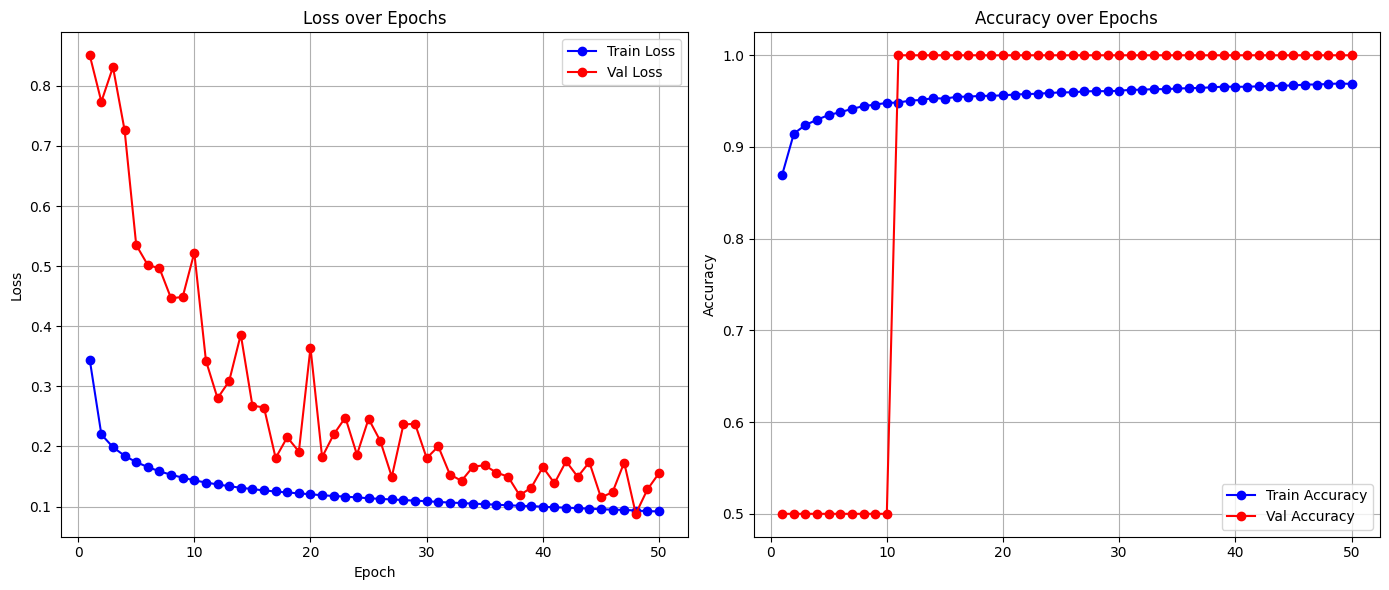

Full model built...
Total execution time: 182.39 seconds
✅ Fold 28 done: Val Loss = 0.1556, Val Acc = 1.0000
Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...
🔍 Inspecting 30-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
Species in validation fold: [np.str_('lythrum_ala

Evaluating: 100%|██████████| 1/1 [00:00<00:00, 798.92it/s]



🔁 Epoch 2/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 681.56it/s]



🔁 Epoch 3/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 851.98it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 911.81it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


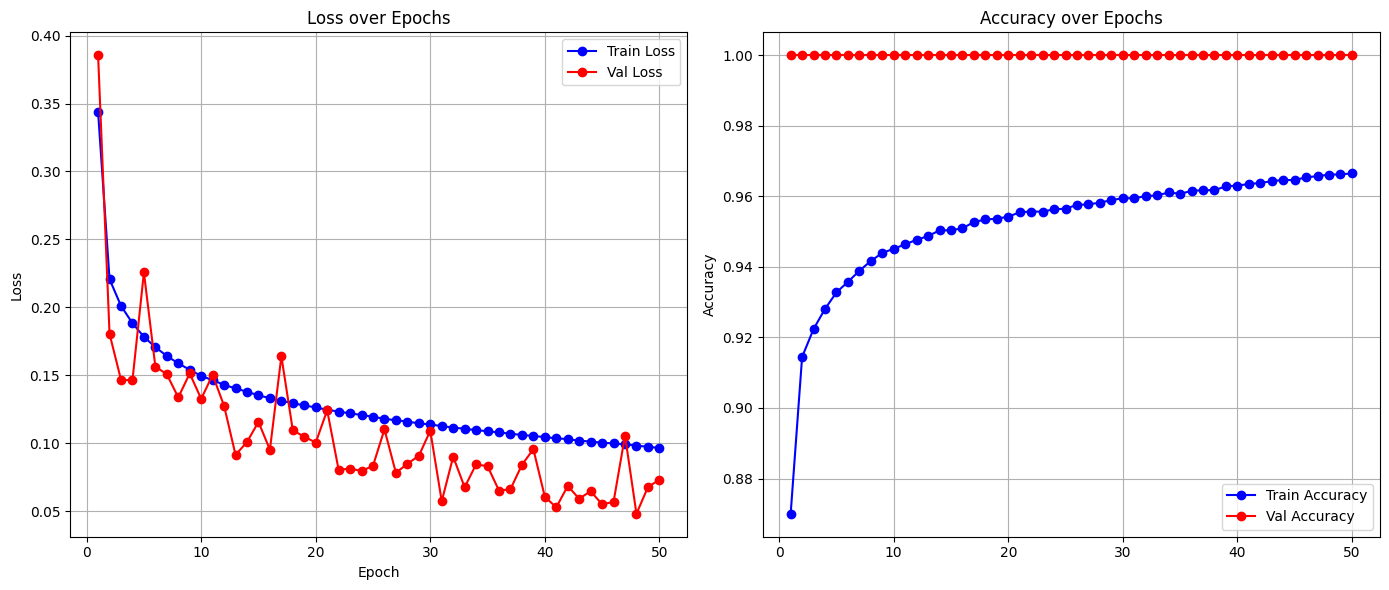

Full model built...
Total execution time: 181.77 seconds
✅ Fold 29 done: Val Loss = 0.0732, Val Acc = 1.0000

📊 Cross-validation results:
Average Validation Loss: 1.0826
Average Validation Accuracy: 0.7313
All Fold Accuracies: [0.5137733689431515, 0.8123153178915261, 0.005739330063654388, 0.31732522796352586, 0.8249896565990897, 0.8599348534201955, 0.5888111888111888, 0.9752808988764045, 0.3342541436464088, 0.8902077151335311, 0.7743362831858407, 0.7875, 0.136986301369863, 0.8442622950819673, 0.7816091954022989, 0.7037037037037037, 0.9629629629629629, 0.0, 0.8333333333333334, 1.0, 1.0, 0.8666666666666667, 1.0, 1.0, 0.875, 0.25, 1.0, 1.0, 1.0, 1.0]

📊 Cross-validation results:
Average Validation Loss (No small species): 1.3161
Average Validation Accuracy (No small species): 0.6734
All Fold Accuracies (No small species): [0.5137733689431515, 0.8123153178915261, 0.005739330063654388, 0.31732522796352586, 0.8249896565990897, 0.8599348534201955, 0.5888111888111888, 0.9752808988764045, 0.334

In [ ]:
all_val_losses = []
all_val_accuracies = []

n_splits = 30

embeddings_save_path_BC2_new = "/content/drive/MyDrive/Thesis/bioclip2_groups_embeddings_v0.pt"
model_name_final = 'group_k_fold_new_embeddings'
epochs=50

for fold_idx in range(n_splits):
  val_loss, val_acc = create_model_and_predict(folder_name="taxas", use_bioclip=True, augmentation=False,
                                          loss_type='CE', bioclip_version=2, output_dir="invasive_species", model_name=model_name_final,
                                           save_model=False, verbose=False, embeddings_save_path=embeddings_save_path_BC2_new,
                                             epochs=epochs, debug_subset_size=None, n_splits=n_splits, fold_idx=fold_idx)
  all_val_losses.append(val_loss)
  all_val_accuracies.append(val_acc)
  print(f"✅ Fold {fold_idx} done: Val Loss = {val_loss:.4f}, Val Acc = {val_acc:.4f}")


mean_loss = sum(all_val_losses) / len(all_val_losses)
mean_acc = sum(all_val_accuracies) / len(all_val_accuracies)

print("\n📊 Cross-validation results:")
print(f"Average Validation Loss: {mean_loss:.4f}")
print(f"Average Validation Accuracy: {mean_acc:.4f}")
print(f"All Fold Accuracies: {all_val_accuracies}")

mean_loss_no_small = sum(all_val_losses[:22]) / len(all_val_losses[:22])
mean_acc_no_small = sum(all_val_accuracies[:22]) / len(all_val_accuracies[:22])

print("\n📊 Cross-validation results:")
print(f"Average Validation Loss (No small species): {mean_loss_no_small:.4f}")
print(f"Average Validation Accuracy (No small species): {mean_acc_no_small:.4f}")
print(f"All Fold Accuracies (No small species): {all_val_accuracies[:22]}")

### Testing on Junceum without Hyssopifolia in the training

Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...
🔍 Inspecting 25-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
Species in validation fold: [np.str_('lythrum_alatum')]

📂 Fold 2: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 9583}
VALIDATION - Total

Evaluating: 100%|██████████| 76/76 [00:00<00:00, 990.13it/s]



🔁 Epoch 2/50


Evaluating: 100%|██████████| 76/76 [00:00<00:00, 1008.10it/s]



🔁 Epoch 3/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 76/76 [00:00<00:00, 1024.76it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 76/76 [00:00<00:00, 1012.96it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


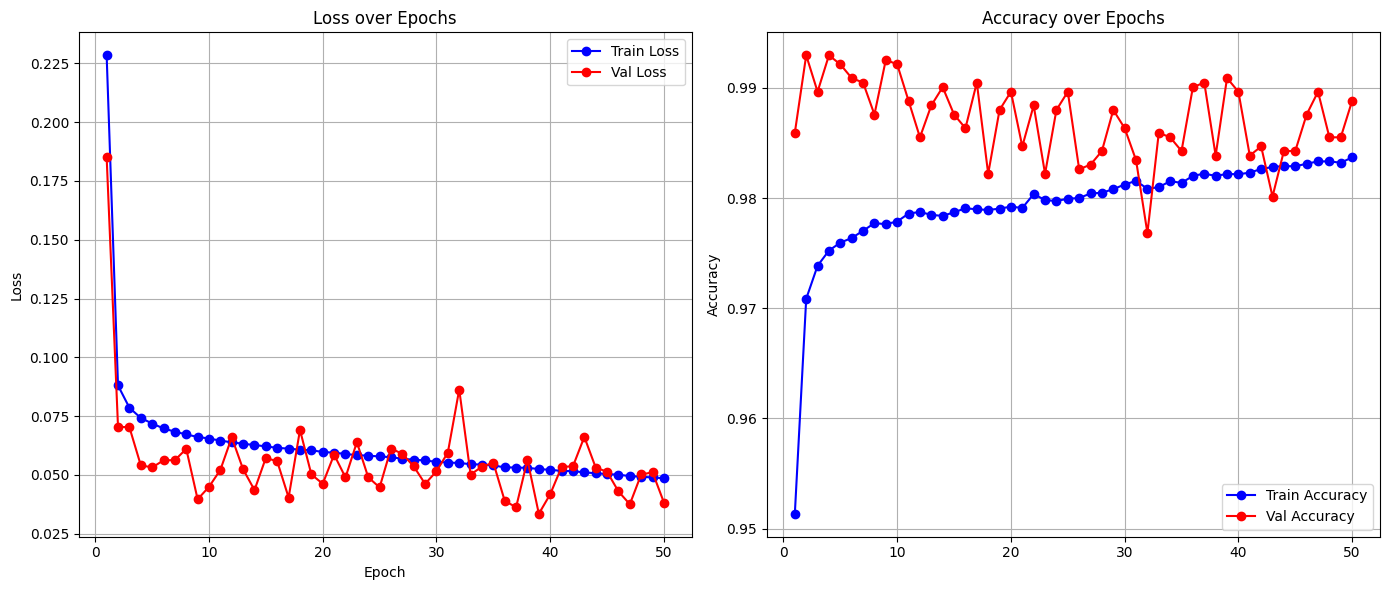

Full model built...
Total execution time: 136.97 seconds


(0.038278548208011, 0.9888291270169631)

In [32]:
embeddings_save_path = "/content/drive/MyDrive/Thesis/bioclip2_groups_embeddings_v0.pt"
epochs=50
n_splits=25
fold_idx=3

create_model_and_predict(folder_name="taxas", use_bioclip=True, augmentation=False,
                                          loss_type='CE', bioclip_version=2, output_dir="invasive_species", model_name='test',
                                           save_model=False, verbose=False, embeddings_save_path=embeddings_save_path,
                                             epochs=epochs, debug_subset_size=None, n_splits=n_splits, fold_idx=fold_idx)

### Testing on Hyssopifolia without Junceum and Portula in the training
#### Junceum and Portula have embeddings close to the Hyssopifolia, but different class

Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...


Extracting embeddings: 100%|██████████| 1418/1418 [36:46<00:00,  1.56s/it]


🔍 Inspecting 25-fold GroupKFold with augmentation effects:
📊 Total samples in original embeddings: 45361
📊 Total unique groups: 30
📊 Total augmented samples (class 1 only): 45361
📊 Augmented class distribution: {np.int64(1): 20528, np.int64(0): 24833}

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
VALIDATION - Total samples: 13105
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (original) - Total samples: 32256
TRAINING (with augmentation) - Class distribution: {np.int64(1): 41056, np.int64(0): 36561}
TRAINING (with augmentation) - Total samples: 77617
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
VALIDATION - Total samples: 10491
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (original) - Total samples: 34870
TRAINING (with augmentation) - Class distribution: {np.

Evaluating: 100%|██████████| 300/300 [00:00<00:00, 1101.96it/s]



🔁 Epoch 2/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 300/300 [00:00<00:00, 1108.31it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 300/300 [00:00<00:00, 1141.44it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


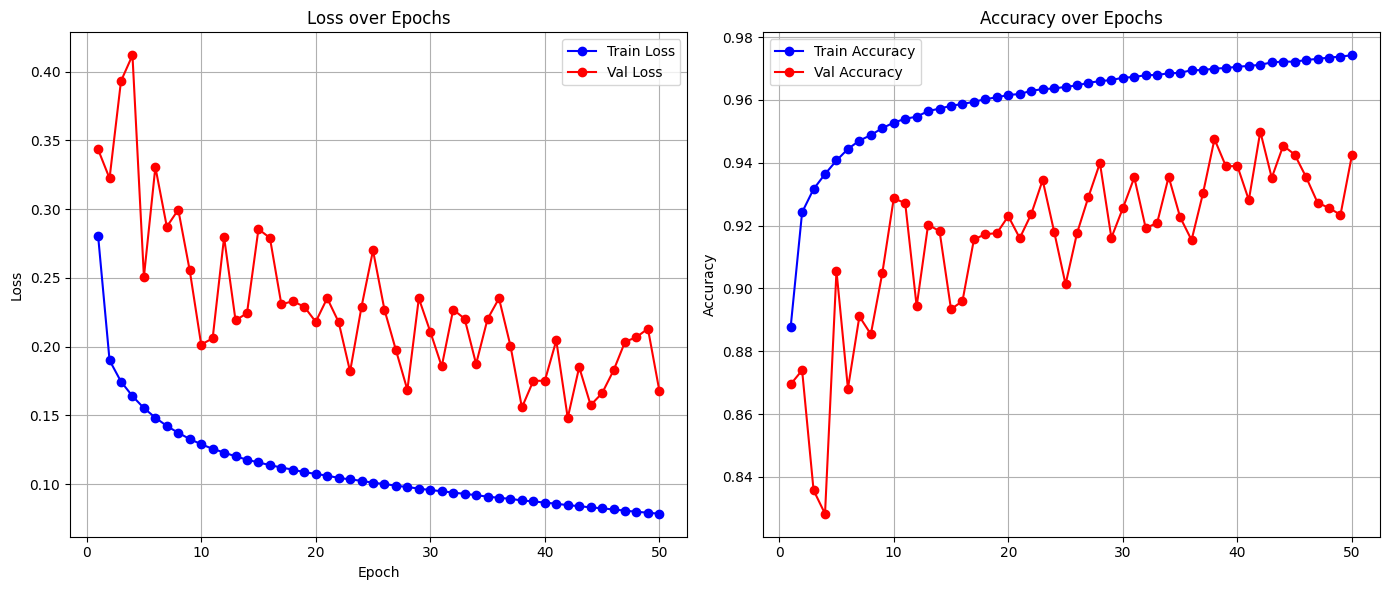

Full model built...
Total execution time: 2494.10 seconds


(0.16780490444458615, 0.9423979964520505)

In [21]:
embeddings_save_path = "/content/drive/MyDrive/Thesis/bioclip2_groups_embeddings_v0.pt"
epochs=50
n_splits=25
fold_idx=2

create_model_and_predict(folder_name="taxas", use_bioclip=True, augmentation=True, augmentation_factor=2,
                                          loss_type='CE', bioclip_version=2, output_dir="invasive_species", model_name='test',
                                           save_model=False, verbose=False, embeddings_save_path=embeddings_save_path,
                                             epochs=epochs, debug_subset_size=None, n_splits=n_splits, fold_idx=fold_idx)

#Slight improvement, not significative.
#Starting from 0.005
#Without Junceum accuracy goes to 0.008, without both Junceum and Portula it goes to 0.014
#Loss is constantly increasing so incresing the training length does not help

#without Junceum and Portula, with augmentation x2, it reaches a 0.942 accuracy with diminishing loss!

### Testing Group K Fold with augmentation x2

Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...


Extracting embeddings: 100%|██████████| 1418/1418 [18:44<00:00,  1.26it/s]


🔍 Inspecting 25-fold GroupKFold with augmentation effects:
📊 Total samples in filtered embeddings: 45361
📊 Total unique groups: 30
📊 Total augmented samples (filtered): 45361
📊 Augmented class distribution: {np.int64(1): 20528, np.int64(0): 24833}

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
TRAINING (original) - Class distribution: {np.int64(1): 20528, np.int64(0): 11728}
TRAINING (with augmentation) - Class distribution: {np.int64(1): 41056, np.int64(0): 36561}
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
TRAINING (original) - Class distribution: {np.int64(1): 10037, np.int64(0): 24833}
TRAINING (with augmentation) - Class distribution: {np.int64(1): 30565, np.int64(0): 49666}
Species in validation fold: [np.str_('lythrum_alatum')]

📂 Fold 2: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 9583}
TRAINING (original) - Class distr

Evaluating: 100%|██████████| 410/410 [00:00<00:00, 1072.66it/s]



🔁 Epoch 2/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 410/410 [00:00<00:00, 1070.87it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 410/410 [00:00<00:00, 1054.19it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


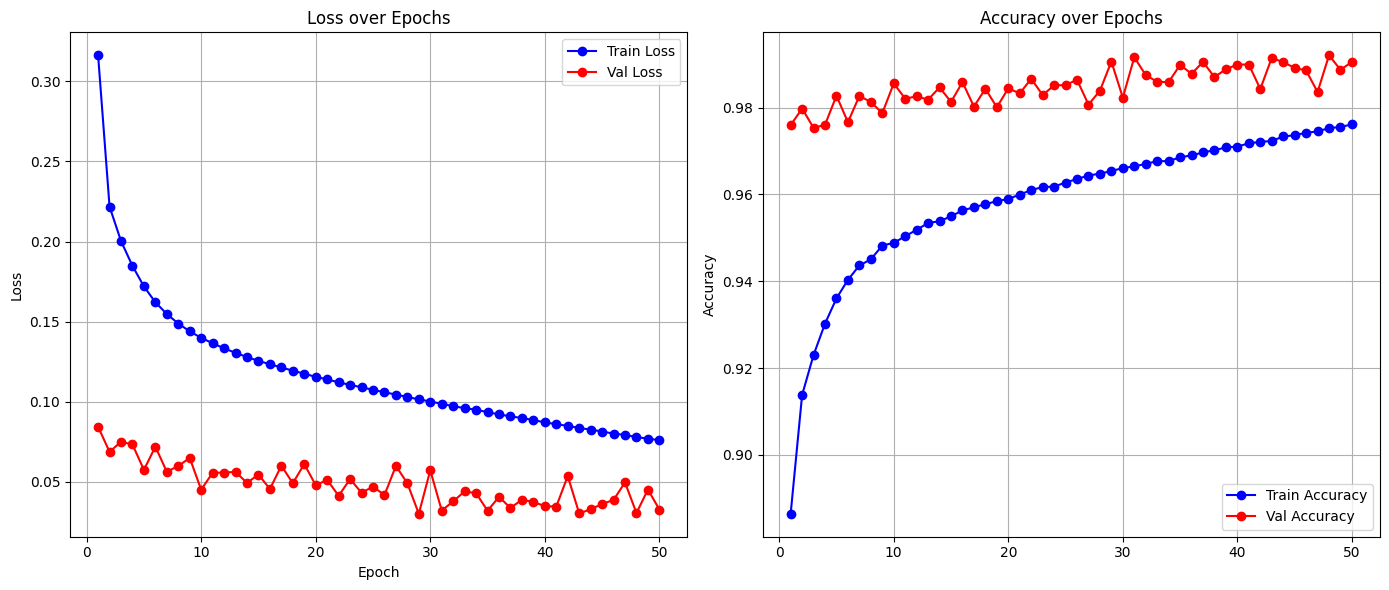

Full model built...
Total execution time: 1386.47 seconds
✅ Fold 0 done: Val Loss = 0.0327, Val Acc = 0.9905
Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...


Extracting embeddings:  48%|████▊     | 678/1418 [09:00<09:49,  1.26it/s]


KeyboardInterrupt: 

In [22]:
all_val_losses = []
all_val_accuracies = []

remove_species=None

n_splits = 25

embeddings_save_path_BC2_new = "/content/drive/MyDrive/Thesis/bioclip2_groups_embeddings_v0.pt"
model_name_final = 'group_k_fold_new_embeddings'
epochs=50

for fold_idx in range(n_splits):
  val_loss, val_acc = create_model_and_predict(folder_name="taxas", use_bioclip=True, augmentation=True, augmentation_factor=2,
                                          loss_type='CE', bioclip_version=2, output_dir="invasive_species", model_name=model_name_final,
                                           save_model=False, verbose=False, embeddings_save_path=embeddings_save_path_BC2_new,
                                             epochs=epochs, debug_subset_size=None, n_splits=n_splits, fold_idx=fold_idx, remove_species=remove_species)
  all_val_losses.append(val_loss)
  all_val_accuracies.append(val_acc)
  print(f"✅ Fold {fold_idx} done: Val Loss = {val_loss:.4f}, Val Acc = {val_acc:.4f}")


mean_loss = sum(all_val_losses) / len(all_val_losses)
mean_acc = sum(all_val_accuracies) / len(all_val_accuracies)

print("\n📊 Cross-validation results:")
print(f"Average Validation Loss: {mean_loss:.4f}")
print(f"Average Validation Accuracy: {mean_acc:.4f}")
print(f"All Fold Accuracies: {all_val_accuracies}")

Using device: cuda
BioCLIP 2!
Model obtained...
Feature extractor obtained..
📊 Total number of taxa (groups): 30
✅ Embeddings already exist, loading from file...


Extracting embeddings: 100%|██████████| 1418/1418 [18:45<00:00,  1.26it/s]


🔍 Inspecting 25-fold GroupKFold with augmentation effects:
📊 Total samples in filtered embeddings: 39654
📊 Total unique groups: 28
📊 Total augmented samples (filtered): 39654
📊 Augmented class distribution: {np.int64(1): 14821, np.int64(0): 24833}

📂 Fold 0: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 13105}
TRAINING (original) - Class distribution: {np.int64(1): 14821, np.int64(0): 11728}
TRAINING (with augmentation) - Class distribution: {np.int64(1): 29642, np.int64(0): 36561}
Species in validation fold: [np.str_('lythrum_salicaria')]

📂 Fold 1: 1 validation groups
VALIDATION - Class distribution: {np.int64(1): 10491}
TRAINING (original) - Class distribution: {np.int64(1): 4330, np.int64(0): 24833}
TRAINING (with augmentation) - Class distribution: {np.int64(1): 19151, np.int64(0): 49666}
Species in validation fold: [np.str_('lythrum_alatum')]

📂 Fold 2: 1 validation groups
VALIDATION - Class distribution: {np.int64(0): 9583}
TRAINING (original) - Class distri

Evaluating: 100%|██████████| 300/300 [00:00<00:00, 1040.25it/s]



🔁 Epoch 2/50


...


🔁 Epoch 49/50


Evaluating: 100%|██████████| 300/300 [00:00<00:00, 1034.00it/s]



🔁 Epoch 50/50


Evaluating: 100%|██████████| 300/300 [00:00<00:00, 1044.29it/s]


📝 Appended log to /content/drive/MyDrive/Thesis/invasive_species/logs/training_log.json


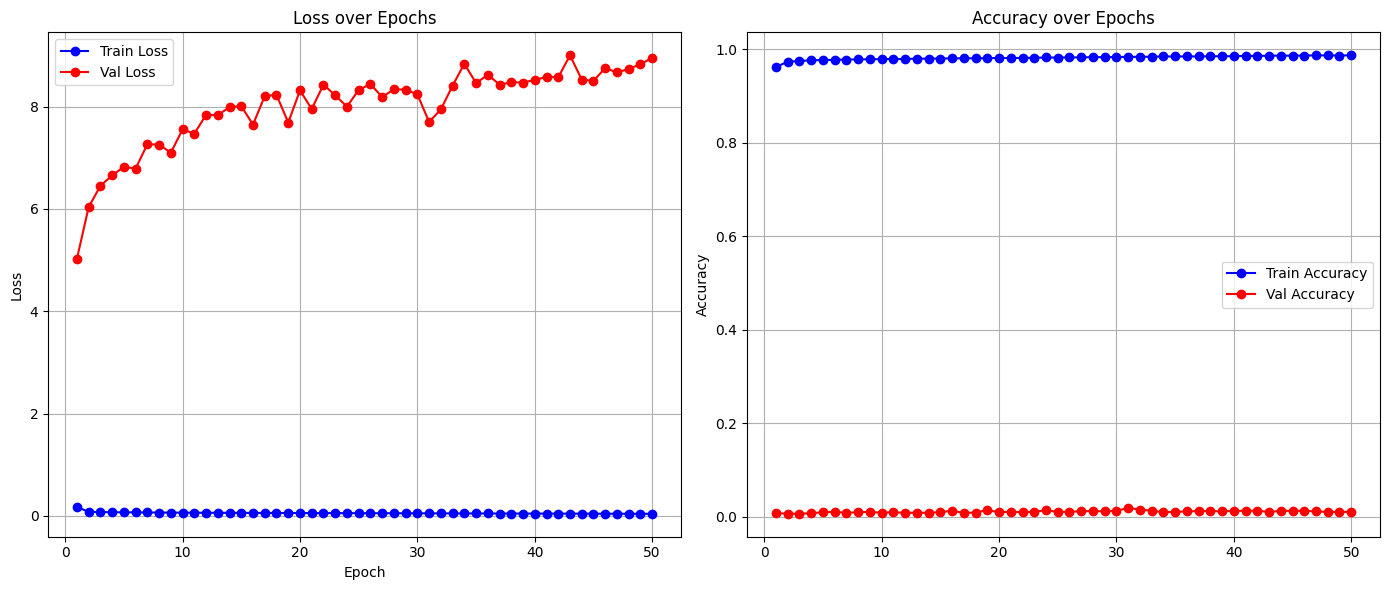

Full model built...
Total execution time: 1333.00 seconds


(8.952324200184052, 0.010539497025983512)

In [24]:
embeddings_save_path = "/content/drive/MyDrive/Thesis/bioclip2_groups_embeddings_v0.pt"
epochs=50
n_splits=25
fold_idx=2
remove_species = ['lythrum_junceum', 'lythrum_portula']

create_model_and_predict(folder_name="taxas", use_bioclip=True, augmentation=True, augmentation_factor=2,
                                          loss_type='CE', bioclip_version=2, output_dir="invasive_species", model_name='test',
                                           save_model=False, verbose=False, embeddings_save_path=embeddings_save_path,
                                             epochs=epochs, debug_subset_size=None, n_splits=n_splits, fold_idx=fold_idx,
                                              remove_species=remove_species)